# <font color="green">**Evaluación comparativa de Regresión Logística y XGBoost para la predicción de riesgo de clientes en un concesionario: Un enfoque interpretable mediante SHAP**



**Integrantes:**
* Ximena Castañeda Ruiz
* Sara Sandoval Alvarez
* Juan Manuel Arredondo

#**Contexto**


La dinámica del sector automotriz, junto con las condiciones cambiantes del entorno económico, ha incrementado la importancia de una adecuada gestión del riesgo crediticio en las empresas dedicadas a la comercialización de vehículos. En particular, los concesionarios que, además de vender automóviles nuevos, usados y usados de otras marcas, ofrecen financiamiento directo a sus clientes, enfrentan el reto constante de evaluar correctamente la capacidad de pago de quienes acceden a crédito. En este contexto, identificar oportunamente a los clientes con mayor probabilidad de atraso en sus obligaciones resulta fundamental para reducir riesgos financieros, optimizar la gestión de cartera y apoyar la toma de decisiones estratégicas dentro de la organización.  Con este propósito, se utilizó una base de datos correspondiente a un concesionario de vehículos que contiene aproximadamente 21,000 registros e incluye información detallada sobre el perfil de los clientes y sus características financieras. Entre las variables disponibles se encuentran indicadores asociados a ingresos, nivel de endeudamiento y obligaciones que permiten describir la capacidad de pago. La variable objetivo, M3_30AC, clasifica a los clientes en dos grupos: aquellos que presentan atraso en sus obligaciones (1) y aquellos que no presentan esta condición (0). Un aspecto crítico de este conjunto de datos es el severo desbalance de clases, donde la proporción de clientes cumplidores es considerablemente mayor, un fenómeno común en la evaluación de riesgo que exige algoritmos robustos para evitar sesgos hacia la clase mayoritaria.  

Para abordar este problema de clasificación binaria, este trabajo propone el desarrollo, optimización y comparación de dos enfoques metodológicos con filosofías distintas:  

* Regresión Logística: Un modelo lineal clásico, altamente valorado en el sector financiero por su simplicidad, velocidad de cómputo y facilidad para interpretar los coeficientes de manera directa.  

* XGBoost (Extreme Gradient Boosting): Un algoritmo avanzado basado en árboles de decisión no lineales que destaca por su alta capacidad predictiva, manejo eficiente de relaciones complejas y robustez frente a datos desbalanceados.

Más allá de la capacidad predictiva pura, las decisiones en el otorgamiento de créditos comerciales requieren de transparencia y justificación regulatoria o institucional. Por ello, este estudio implementa SHAP (SHapley Additive exPlanations), una herramienta basada en la teoría de juegos cooperativos que permite abrir la "caja negra" de modelos complejos como XGBoost. A través de SHAP, se busca garantizar la interpretabilidad global y local del modelo seleccionado, validando el sentido financiero de las predicciones y permitiendo auditar de manera individual las razones por las cuales un cliente es clasificado como riesgoso.

#**Planteamiento del problema**

El presente estudio aborda un problema de clasificación binaria, cuyo objetivo es predecir si un cliente presentará atraso en el pago de sus obligaciones crediticias.

La variable objetivo utilizada es M3_30AC, la cual toma el valor de:

1: cliente con atraso
0: cliente sin atraso

Este problema es relevante debido a que errores en la clasificación pueden generar impactos significativos en la organización. Por un lado, clasificar incorrectamente a un cliente riesgoso como no riesgoso puede derivar en pérdidas financieras; por otro lado, rechazar clientes con buen comportamiento de pago puede afectar la competitividad del concesionario.

Adicionalmente, el conjunto de datos presenta un desbalance significativo entre las clases, lo cual representa un desafío para los modelos de clasificación, ya que pueden tender a favorecer la clase mayoritaria y reducir su capacidad de identificar correctamente a los clientes en riesgo.

#**Enfoque del trabajo**
El desarrollo del estudio se estructura en varias etapas consecutivas que inician con un Análisis Exploratorio de Datos (EDA) para identificar distribuciones y variables con potencial capacidad discriminante. Posteriormente, el preprocesamiento de datos aborda el tratamiento de valores faltantes y la codificación de variables categóricas, aplicando un criterio de escalamiento diferenciado: las variables numéricas se escalan únicamente para la Regresión Logística, mientras que para XGBoost se conservan en su escala real para facilitar la posterior validación manual de perfiles de clientes. Para mitigar el desbalance de la variable objetivo, se implementa una estrategia de remuestreo o ajuste de pesos en el conjunto de entrenamiento. Luego, ambos modelos se optimizan mediante Random Search y se evalúan críticamente en función de su capacidad predictiva, sobreajuste y generalización. Finalmente, tras seleccionar el mejor clasificador, se realiza un análisis de interpretabilidad avanzada global y local mediante valores SHAP, concluyendo con la simulación y auditoría de diez clientes ficticios en escala real para verificar la coherencia lógica y comercial del modelo.

#**Objetivo General**

Desarrollar y comparar modelos de clasificación basados en Regresión Logística y XGBoost para identificar clientes con riesgo de atraso en sus obligaciones crediticias en un concesionario de vehículos, evaluando su desempeño predictivo mediante métricas financieras y garantizando la interpretabilidad de las decisiones a través del análisis avanzado con SHAP

#**Objetivos específicos**

* Implementar un flujo de preprocesamiento de datos diferenciado que aplique escalamiento numérico exclusivamente para la Regresión Logística, preservando las variables en su escala real para el entrenamiento de XGBoost.  
* Optimizar los hiperparámetros de ambos modelos mediante la estrategia de Random Search para maximizar la capacidad de generalización y mitigar el efecto del desbalance de clases.  
* Evaluar y comparar críticamente el rendimiento de ambos algoritmos en términos de capacidad predictiva, sobreajuste y la naturaleza de sus fronteras de decisión (lineal vs. no lineal).  
* Explicar el comportamiento global y local del mejor modelo seleccionado utilizando gráficos de SHAP (Summary, Bar, Beeswarm y Dependence), asegurando una justificación técnica, financiera y comercial de las variables.  
* Validar de forma manual el modelo final mediante la simulación y auditoría de 10 perfiles de clientes ficticios en escala real, verificando la coherencia lógica de las probabilidades de riesgo asignadas.


# **Librerias**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

**Cargar Base de Datos**

In [ ]:
import pandas as pd
import requests

file_id = '12xu_aDpj2d3SzX5L2UtEGKYj_FxZFSuG'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_excel(url)

# **Limpieza y transformación de los datos:**

## **Visualización previa de bases de datos**

In [ ]:
df.head()

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


## **Dimensiones y tipos de datos**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  object 
 2   Estado                  21091 non-null  object 
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  object 
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ MB


La base de datos cuenta con 21,091 registros y 13 variables, donde predomina el tipo numérico.

El dataset contiene una combinación de datos numéricos y categóricos, lo cual es característico en información asociada al análisis crediticio. Esta diversidad de variables permite capturar distintos aspectos del perfil del cliente, incluyendo su capacidad de pago y comportamiento financiero.

**Descripción del conjunto de datos**

Esta base de datos contiene información de perfilamiento crediticio de clientes, diseñada para analizar el comportamiento financiero y el riesgo de impago. El dataset se compone de variables demográficas (como edad y género), indicadores financieros (como ingresos estimados, gastos mensuales y capacidad de pago) y datos contractuales del crédito (como el plazo, el monto de la cuota y el porcentaje de financiación solicitado). Además, incluye un indicador de riesgo llamado Score Crediticio, que mide la confiabilidad del cliente, y la variable objetivo M3_30AC, la cual identifica si el usuario presenta un incumplimiento o mora mayor a 30 días.

## **Datos duplicados**

En esta etapa del preprocesamiento, se busca identificar registros duplicados dentro de las bases de datos. La presencia de duplicados puede afectar la calidad del análisis, generando sesgos en los resultados o inflando la representatividad de ciertos casos. Para ello, se utilizó el método .duplicated() de pandas, que permite detectar filas repetidas en su totalidad.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
duplicadas = df.T.duplicated() # identificar columnas duplicadas
print(duplicadas)

Caso                      False
Perfil                    False
Estado                    False
Edad                      False
Genero                    False
ScoreCrediticio           False
PorcentajeFinanciacion    False
Plazo                     False
IngresoEstimado           False
Gastos                    False
CapacidadDePago           False
ValorCuotaMensual         False
M3_30AC                   False
dtype: bool


Encontramos que no hay datos duplicados en la base de datos.

**Inspección de estadísticas**

In [ ]:
df.describe()

,Caso,Edad,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
count,2.109100e+04,21091.000000,21091.000000,21091.000000,21091.000000,2.106300e+04,2.109100e+04,2.106300e+04,2.109100e+04,21091.000000
mean,1.006177e+09,44.549144,782.370774,0.743518,60.632260,5.018901e+06,1.141223e+08,-8.077237e+01,1.703957e+06,0.039685
std,3.264523e+05,12.747788,85.332411,0.246627,12.495909,5.955286e+06,1.623579e+10,1.198892e+04,8.595178e+05,0.195223
min,1.004992e+09,19.000000,343.000000,0.100000,12.000000,0.000000e+00,3.685310e+05,-1.739961e+06,1.500000e+05,0.000000
25%,1.005912e+09,34.000000,726.000000,0.552250,60.000000,1.596674e+06,1.090507e+06,2.454135e-01,1.158444e+06,0.000000
50%,1.006159e+09,43.000000,783.000000,0.800000,60.000000,2.985320e+06,1.672997e+06,9.132229e-01,1.557124e+06,0.000000
75%,1.006453e+09,54.000000,838.000000,1.000000,72.000000,5.797367e+06,2.736073e+06,2.150520e+00,2.062300e+06,0.000000
max,1.006786e+09,75.000000,999.000000,1.067000,84.000000,3.480000e+07,2.357884e+12,1.207657e+02,1.861680e+07,1.000000


En general, los datos muestran que la mayoría de los clientes son adultos, con una edad promedio de 44 años, y con un comportamiento financiero relativamente estable.

En cuanto al historial crediticio, la mayoría de los clientes tiene un buen puntaje. El promedio está alrededor de 782, lo que indica que, en general, son personas que han manejado bien sus créditos en el pasado. Esto sugiere que la base no está compuesta por clientes riesgosos, sino más bien por personas confiables para otorgarles financiación.

Respecto a los ingresos, se observa que la mayoría de las personas gana entre 1.5 y 5.8 millones, aunque hay algunos casos con ingresos muy altos que hacen que el promedio suba. Esto significa que no todos los clientes tienen el mismo nivel económico, pero la mayoría se encuentra en un rango medio. Sin embargo, al revisar los gastos, hay valores extremadamente altos que no parecen realistas, lo que indica que puede haber errores en esa información.

En cuanto a las características del crédito, la mayoría de los préstamos se otorgan a plazos cercanos a los 5 años, con cuotas mensuales alrededor de 1.5 a 2 millones. Además, el porcentaje de financiación suele ser alto, en muchos casos cercano al 100%, lo que indica que las personas financian casi todo el valor del bien o servicio.

Finalmente, la proporción de clientes que presentan mora es baja, aproximadamente un 4%. Esto significa que la gran mayoría de las personas cumple con sus pagos. Sin embargo, también implica que hay pocos casos de incumplimiento, lo que puede dificultar identificar patrones claros de riesgo.

## **Datos faltantes**

In [ ]:
df.isnull().sum().sort_values(ascending=False).head()

,0
IngresoEstimado,28
CapacidadDePago,28
Estado,0
Perfil,0
Caso,0


Encontramos que las columnas de Ingreso Estimado y Capacidad de Pago tienen 28 espacios vacíos cada una.

Como son solo 28 casos frente a un total de 21,091, lo más sencillo y seguro es eliminar esas 28 filas. No perderemos información importante y limpiaremos la base de datos para que el modelo funcione correctamente.

In [ ]:
# Eliminamos las filas que tienen datos vacíos
df = df.dropna(subset=['IngresoEstimado', 'CapacidadDePago'])
print(df.isnull().sum())

Caso                      0
Perfil                    0
Estado                    0
Edad                      0
Genero                    0
ScoreCrediticio           0
PorcentajeFinanciacion    0
Plazo                     0
IngresoEstimado           0
Gastos                    0
CapacidadDePago           0
ValorCuotaMensual         0
M3_30AC                   0
dtype: int64


La variable objetivo M3_30AC indica si un cliente presenta mora o no en sus pagos, donde el valor 0 representa cumplimiento y el valor 1 indica incumplimiento. Esta variable es clave para el análisis, ya que permite identificar el riesgo crediticio de los clientes. En la base de datos se observa que la gran mayoría de los casos corresponden a clientes que cumplen con sus obligaciones, mientras que una pequeña proporción presenta mora, lo que evidencia un desbalance importante entre las clases. Este comportamiento es relevante porque influye directamente en la forma en que se deben analizar los datos y construir modelos predictivos.

# **Análisis Exploratorio**

# **Variable Objetivo**

La variable M3_30AC es la variable objetivo del análisis y representa el estado de mora de los clientes. Es una variable binaria, donde el valor 0 indica que el cliente no presenta mora (cumple con sus pagos) y el valor 1 indica que el cliente sí presenta mora (incumple sus obligaciones). Esta variable es fundamental, ya que permite identificar el nivel de riesgo crediticio y diferenciar entre clientes buenos y clientes con comportamiento de incumplimiento

In [ ]:
df['M3_30AC'].value_counts()

,count
M3_30AC,
0,20228
1,835


La variable M3_30AC presenta un desbalance claro entre sus categorías. De un total de 21,063 registros, 20,228 corresponden a clientes que no entran en mora (0), mientras que solo 835 sí presentan mora (1). Esto significa que aproximadamente el 96% de los casos son positivos (buenos clientes) y apenas un 4% son negativos (clientes en mora). En términos prácticos, el modelo va a “aprender” mucho más sobre los clientes que pagan bien y muy poco sobre los que incumplen. Como consecuencia, podría predecir casi siempre que nadie entra en mora y aun así tener una aparente buena precisión, pero en realidad sería poco útil para detectar riesgo, que es lo más importante en este caso.

## **Remuestreo**

Se decidió reducir la clase mayoritaria a 1,670 registros, estableciendo una proporción 2:1 frente a la clase minoritaria (835 casos), con el fin de disminuir el desbalance sin perder una cantidad excesiva de información. Esta proporción permite que el modelo tenga suficientes ejemplos de ambas clases para aprender a diferenciar el riesgo de mora, manteniendo al mismo tiempo una representación adecuada de la población original. De esta manera, se logra un equilibrio entre calidad del modelo y conservación de datos.

In [ ]:
from sklearn.utils import resample

# Separar clases
df_mayor = df[df['M3_30AC'] == 0]
df_menor = df[df['M3_30AC'] == 1]

# Definir tamaño deseado
n_muestra = 1670

# Tomar muestra aleatoria de la clase mayoritaria
df_mayor_sample = resample(df_mayor,replace=False,   # sin reemplazo
                          n_samples=n_muestra,random_state=42)

df_balanceado = pd.concat([df_mayor_sample, df_menor])

In [ ]:
df_balanceado['M3_30AC'].value_counts()

,count
M3_30AC,
0,1670
1,835


### **Variable `Caso`**

La variable `Caso` fue eliminada del análisis debido a que corresponde a un identificador único para cada registro y no aporta información relevante sobre el comportamiento del cliente. Por esta razón, se decide excluirla para garantizar un análisis más limpio y enfocado en variables con valor explicativo.

## **Análisis univariado de Variables Númericas**

In [ ]:
!pip install ptitprince

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

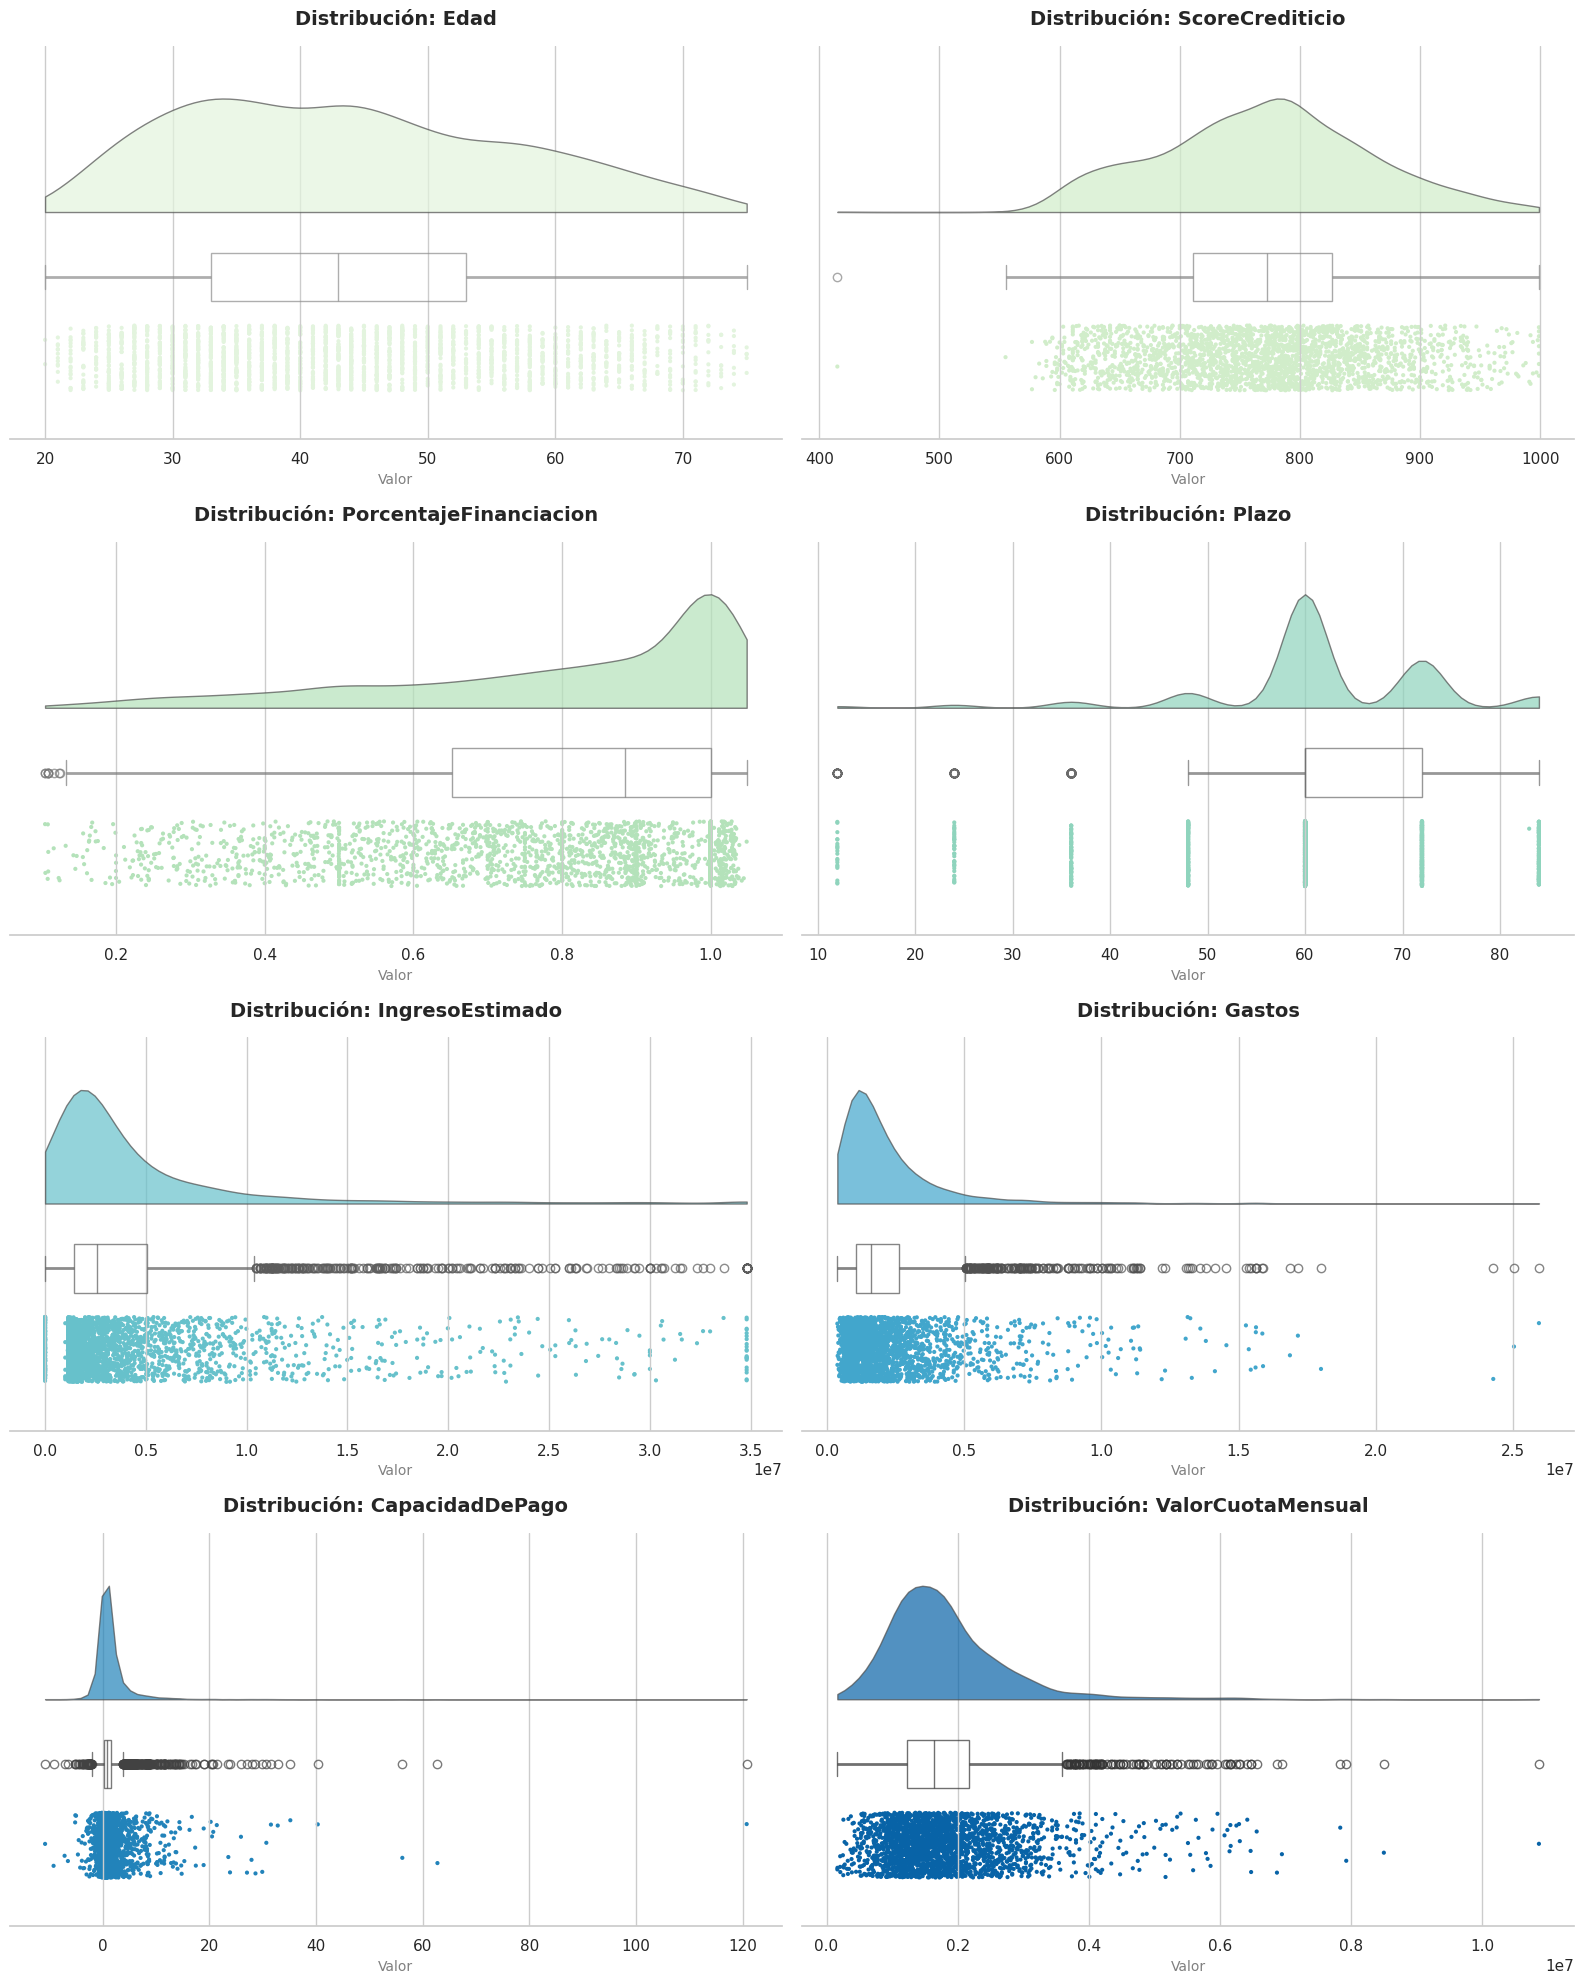

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt
num_cols = df_balanceado.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop(['M3_30AC', 'Caso'])

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

cols_a_graficar = list(num_cols)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()
colors = sns.color_palette("GnBu", len(cols_a_graficar))

for i, col in enumerate(cols_a_graficar):
    if i < len(axes):
        pt.RainCloud(y=df_balanceado[col], ax=axes[i],
                     orient="h",
                     palette=[colors[i]], # Color por gráfico
                     bw=.2,               # Suavizado de la nube
                     width_viol=.7,       # Tamaño de la distribución
                     width_box=.15,       # Grosor del boxplot
                     alpha=.7,            # Transparencia profesional
                     move=.25)            # Separación entre elementos

        axes[i].set_title(f'Distribución: {col}', fontsize=14, fontweight='bold', pad=15)
        axes[i].set_xlabel('Valor', fontsize=10, color='gray')
        axes[i].set_ylabel('')
        sns.despine(ax=axes[i], left=True)

for j in range(len(cols_a_graficar), len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
plt.show()

**Edad:** Es la variable con la distribución más equilibrada y sana. Cubre un rango amplio sin huecos ni valores imposibles, lo que permitirá al modelo entender el comportamiento según la etapa de vida de manera estable.

**Score Crediticio:** Muestra una curva de campana saludable desplazada hacia puntajes altos(800+). No obstante, los puntos que "caen" hacia los 400 puntos son muy buenos para el modelo, ya que representan el comportamiento histórico de riesgo que debe identificar.

**Ingreso Estimado:** Presenta una concentración masiva en valores bajos con una "cola" muy larga hacia la derecha. Unos pocos clientes con ingresos altísimos podrían distorsionar el promedio y afectar el modelo.

**Gastos:** La mayoría de los datos están agrupados al inicio. Sin embargo, hay puntos aislados en el extremo derecho que parecen casos extremadamente atípicos; es vital tratarlos antes del modelo

**Capacidad de Pago:** Es la variable más reveladora. La "nube" es muy estrecha y está centrada en cero, pero lo más importante son los valores negativos. Estos representan clientes que gastan más de lo que ganan, siendo probablemente el mayor indicador de riesgo de mora.

**Valor Cuota Mensual:** Muestra una distribución muy sesgada hacia cuotas bajas. Esto indica que el portafolio está compuesto principalmente por microcréditos o créditos de consumo masivo, con muy pocos casos de cuotas elevadas.

**Plazo:** Refleja que los créditos se otorgan en plazos estándar (ej. 36, 48, 60 meses). El modelo puede tratar esto casi como una variable por categorías.

**Porcentaje de Financiación:** La mayoría de los clientes están agrupados cerca del 90% y 100%. Esto significa que casi todos piden el máximo posible, lo que deja poco margen de garantía

In [ ]:
df_balanceado['Plazo'].value_counts()

,count
Plazo,
60,1438
72,602
48,188
84,143
36,76
24,37
12,20
83,1


El plazo no se comporta como una variable continua, cuando una variable numérica tiene pocos valores únicos y mucha repetición, se comporta más como una "etiqueta" de producto bancario que como una medida física. Al hacerla categórica, el modelo no intenta adivinar qué pasa en el mes 75 (donde no hay datos)

La existencia de un único registro con valor 83 se identifica como un error. Por eso se corrigió poniendo el valor mas cercano que es 84.

In [ ]:
df_balanceado['Plazo'] = df_balanceado['Plazo'].replace(83, 84)

In [ ]:
df_balanceado['Plazo'].value_counts()

,count
Plazo,
60,1438
72,602
48,188
84,144
36,76
24,37
12,20


## **Análisis univariado de Variables Categoricas**

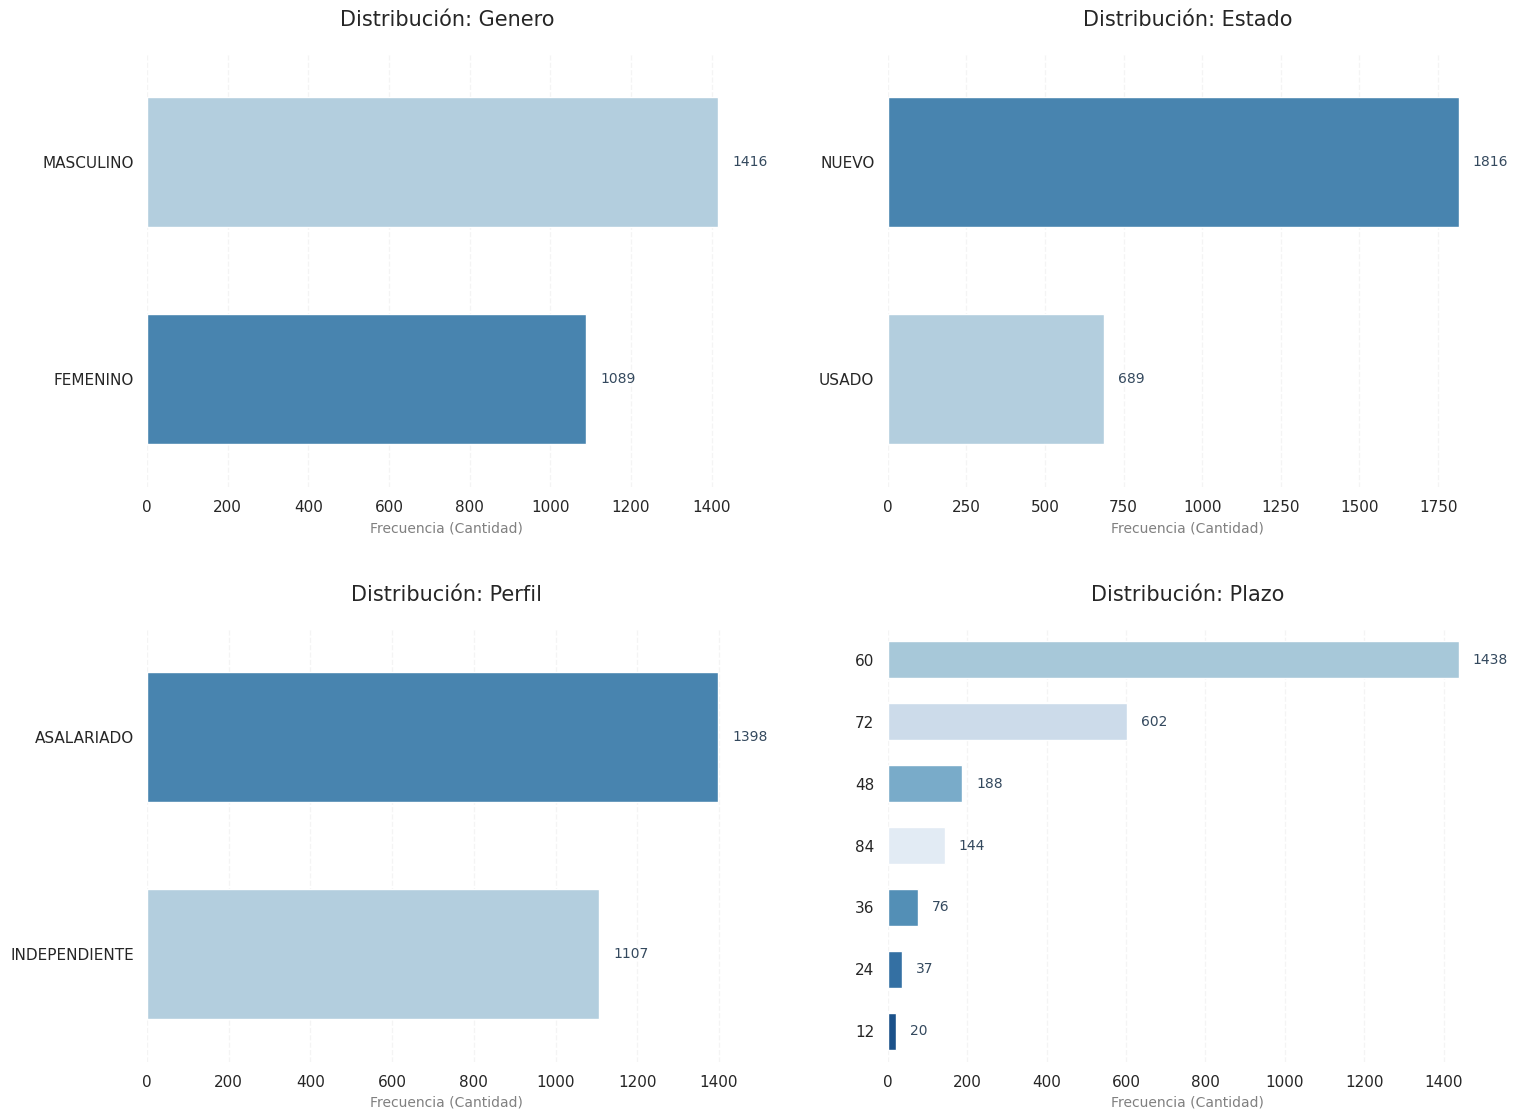

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

cat_cols = ['Genero', 'Estado', 'Perfil', 'Plazo']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_balanceado[col].value_counts()
    order = counts.index
    pal = sns.color_palette("Blues_r", n_colors=len(order))

    sns.countplot(data=df_balanceado, y=col, ax=axes[i],
                  order=order, palette=pal, hue=col, legend=False,
                  width=0.6)

    # Añadir etiquetas de conteo al final de las barras
    for p in axes[i].patches:
        width_val = p.get_width()
        if width_val > 0: # Evita errores si hay categorías vacías
            axes[i].annotate(f'{int(width_val)}',
                             (width_val, p.get_y() + p.get_height() / 2.),
                             ha='left', va='center',
                             xytext=(10, 0),
                             textcoords='offset points',
                             fontsize=10,
                             color='#34495e')

    axes[i].set_title(f'Distribución: {col}', fontsize=15, pad=20)
    axes[i].set_xlabel('Frecuencia (Cantidad)', fontsize=10, color='gray')
    axes[i].set_ylabel('')

    sns.despine(ax=axes[i], left=True, bottom=True)
    axes[i].grid(axis='x', linestyle='--', alpha=0.2)

plt.tight_layout(pad=3.0)
plt.show()

**Género:** Existe una distribución relativamente equilibrada, aunque con una mayor presencia de Masculinos (1,416) frente a Femeninos (1,089). Esto es bueno porque el modelo no se enfocará en un solo grupo, sino que aprenderá de ambos.

**Perfil Laboral:** La mayoría de clientes son empleados (asalariados), seguidos de cerca por los independientes. Esto es clave, porque un empleado suele tener un sueldo fijo, mientras que el independiente varía. El modelo tendrá que aprender a distinguir quién es más cumplido según cómo recibe su dinero.

**Estado:** Hay una preferencia gigante por lo nuevo. La gran mayoría de créditos son para estrenar.

**Plazo (Categorizado):** El gráfico confirma la decisión de tratarlo como categoría. El plazo de 60 meses es el líder absoluto con 1,438 casos, seguido por el de 72 meses. Son muy poquitos los que piden créditos a un año. Esto nos dice que los clientes prefieren cuotas más bajitas aunque tarden más en pagar.

## **Análisis Bivariado**

### <font color="PURPLE"> **Gráfico de Barras Apiladas**

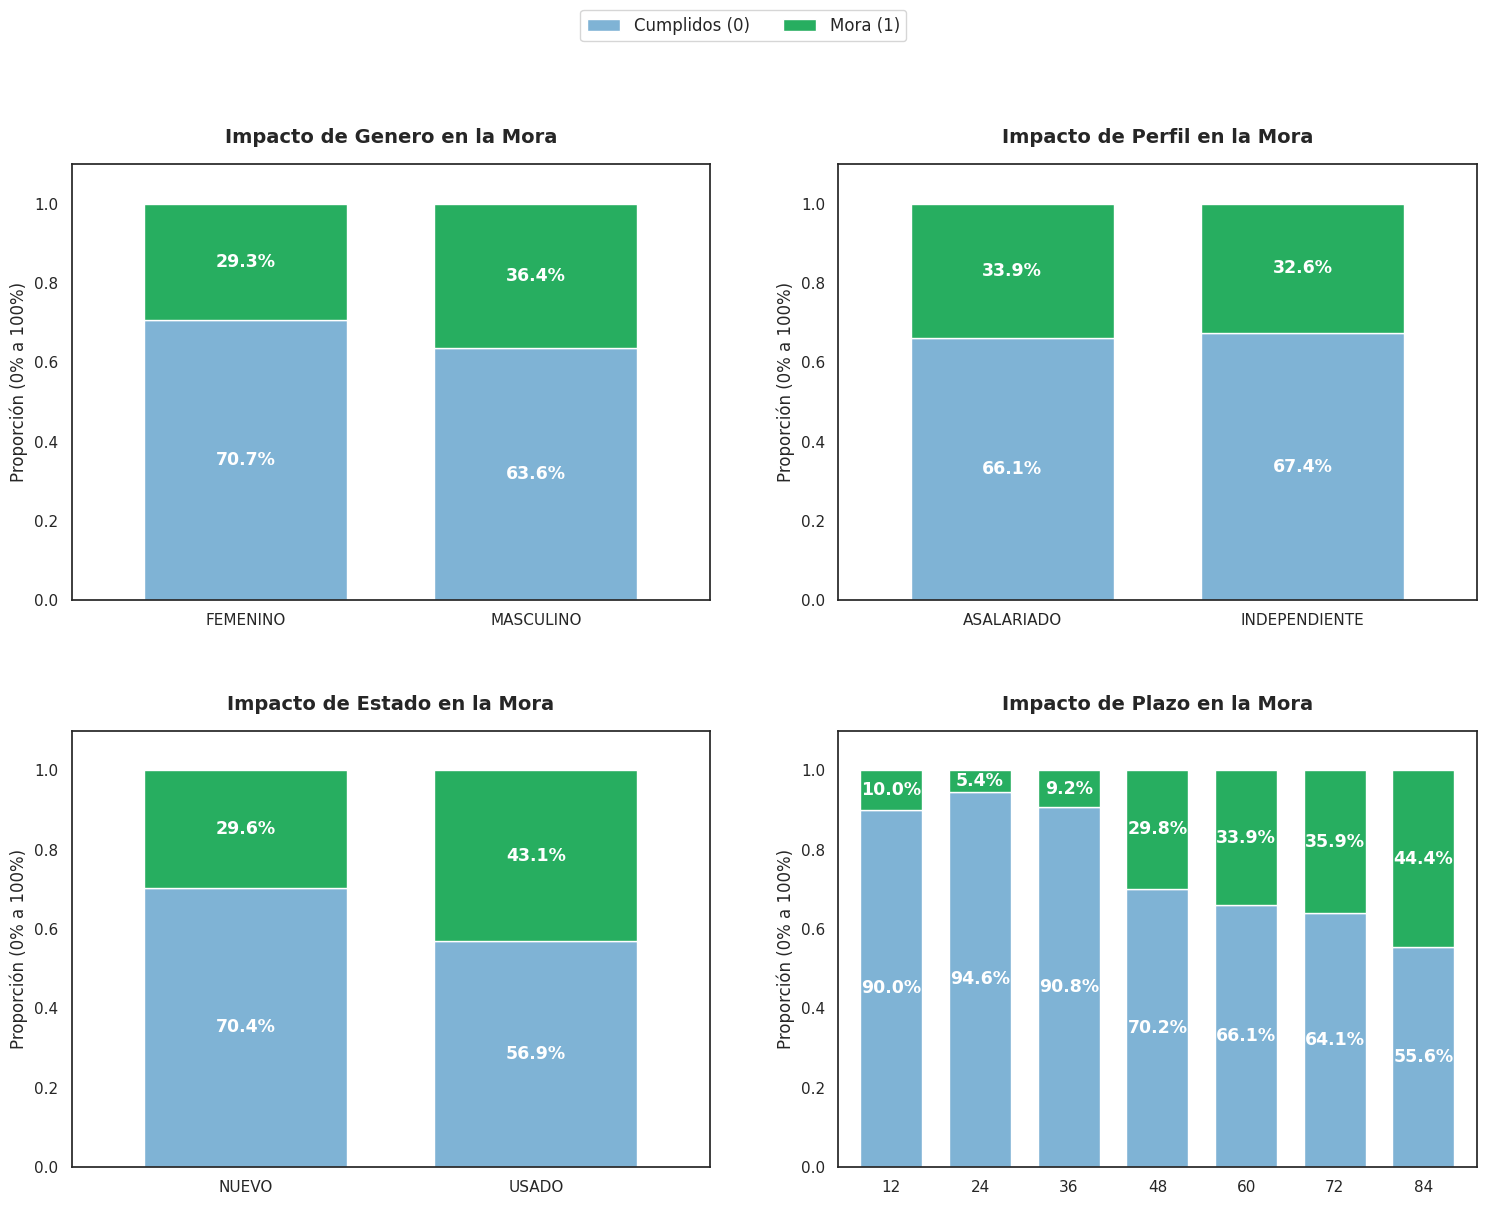

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

vars_cat = ['Genero', 'Perfil', 'Estado', 'Plazo']
n_vars = len(vars_cat)
cols = 2
rows = math.ceil(n_vars / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()
colores = ['#7FB3D5', '#27AE60']

for i, var in enumerate(vars_cat):
    contingency_pct = pd.crosstab(df_balanceado[var], df_balanceado['M3_30AC'], normalize='index')

    ax = axes[i]
    contingency_pct.plot(kind='bar', stacked=True, color=colores, ax=ax, legend=False, width=0.7)
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 0.05:
            ax.annotate(f'{height:.1%}',
                        (p.get_x() + width/2, p.get_y() + height/2),
                        ha='center', va='center',
                        color='white', fontweight='bold', fontsize=12.5)

    ax.set_title(f'Impacto de {var} en la Mora', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Proporción (0% a 100%)')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=0)

plt.figlegend(['Cumplidos (0)', 'Mora (1)'], loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(pad=4.0)
plt.show()

Se analizó el comportamiento de la mora según diferentes variables categóricas. Este análisis permite identificar cuáles factores están más asociados al incumplimiento de los clientes.

**1. Plazo**

Es la variable que presenta la relación más clara con la mora. Se observa que, a medida que aumenta el tiempo del crédito, también aumenta la probabilidad de incumplimiento. Los créditos de corto plazo (entre 12 y 36 meses) muestran niveles bajos de mora, mientras que los plazos más largos, especialmente 84 meses, presentan porcentajes considerablemente más altos.

Además, se identifica un cambio importante a partir de los 48 meses, donde el riesgo aumenta de forma significativa. Esto indica que los plazos largos representan un mayor nivel de riesgo para la entidad.

**2. Estado (Nuevo vs Usado)**

El estado del bien financiado también muestra una diferencia clara en el nivel de riesgo. Los créditos asociados a bienes usados presentan una mayor proporción de mora en comparación con los bienes nuevos.

Esto sugiere que financiar bienes usados implica un mayor riesgo, posiblemente porque están asociados a mayores costos adicionales o a perfiles de clientes con menor estabilidad económica.

**3. Género**

Se observa una diferencia moderada entre los grupos. Los clientes masculinos presentan una mayor proporción de mora en comparación con los femeninos, aunque la diferencia no es tan marcada como en otras variables. Esto indica que, si bien el género tiene cierta influencia, no es un factor determinante por sí solo.

**4. Perfil (Asalariado vs Independiente)**

El perfil laboral es la variable que presenta menor diferencia entre categorías. Tanto los clientes asalariados como los independientes muestran niveles de mora muy similares, lo que indica que esta característica no permite diferenciar claramente entre clientes con mayor o menor riesgo.

Esto sugiere que, por sí sola, esta variable no es suficiente para explicar el comportamiento de pago.

### <font color="PURPLE"> **Point Plot (Gráfico de Puntos) con Intervalos de Confianza.**

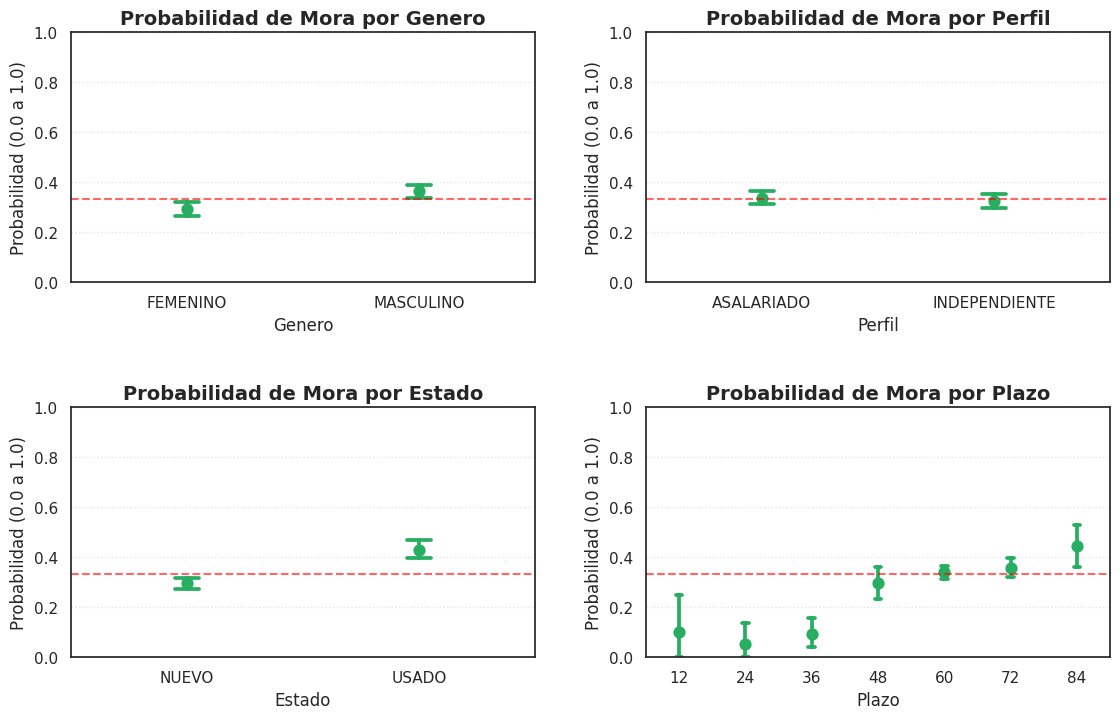

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

vars_cat = ['Genero', 'Perfil', 'Estado', 'Plazo']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
    sns.pointplot(data=df_balanceado, x=var, y="M3_30AC", ax=axes[i],
                  join=False, color='#27AE60', capsize=.1, errorbar=('ci', 95))
    tasa_promedio = df_balanceado['M3_30AC'].mean()
    axes[i].axhline(tasa_promedio, color='red', linestyle='--', alpha=0.6, label='Tasa Promedio')

    axes[i].set_title(f'Probabilidad de Mora por {var}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Probabilidad (0.0 a 1.0)')
    axes[i].set_ylim(0, 1)
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout(pad=3.0)
plt.show()

Para complementar el análisis anterior, debemos enfocarnos en la estabilidad y la significancia estadística que aportan los Point Plots. Mientras las barras nos dicen "qué pasó", estos gráficos nos dicen "qué tan probable es que esto se repita en el futuro".

* El plazo mantiene una tendencia clara, a medida que aumenta, también lo hace la probabilidad de mora. Este comportamiento es progresivo y constante, lo que indica que el riesgo crece de forma directa con el tiempo del crédito.

* El estado del bien (nuevo o usado) presenta una diferencia clara y estable. Los bienes usados mantienen un nivel de mora mayor en comparación con los nuevos, y esta diferencia se observa de forma consistente.

* El género muestra una diferencia moderada en la probabilidad de mora. Aunque los clientes masculinos presentan un mayor nivel de incumplimiento, la diferencia no es tan amplia.

* El perfil laboral no presenta diferencias relevantes. Los resultados de ambas categorías son muy similares, lo que indica que esta variable no permite distinguir claramente entre clientes con mayor o menor riesgo.

### <font color="PURPLE"> **Matriz de Correlación**

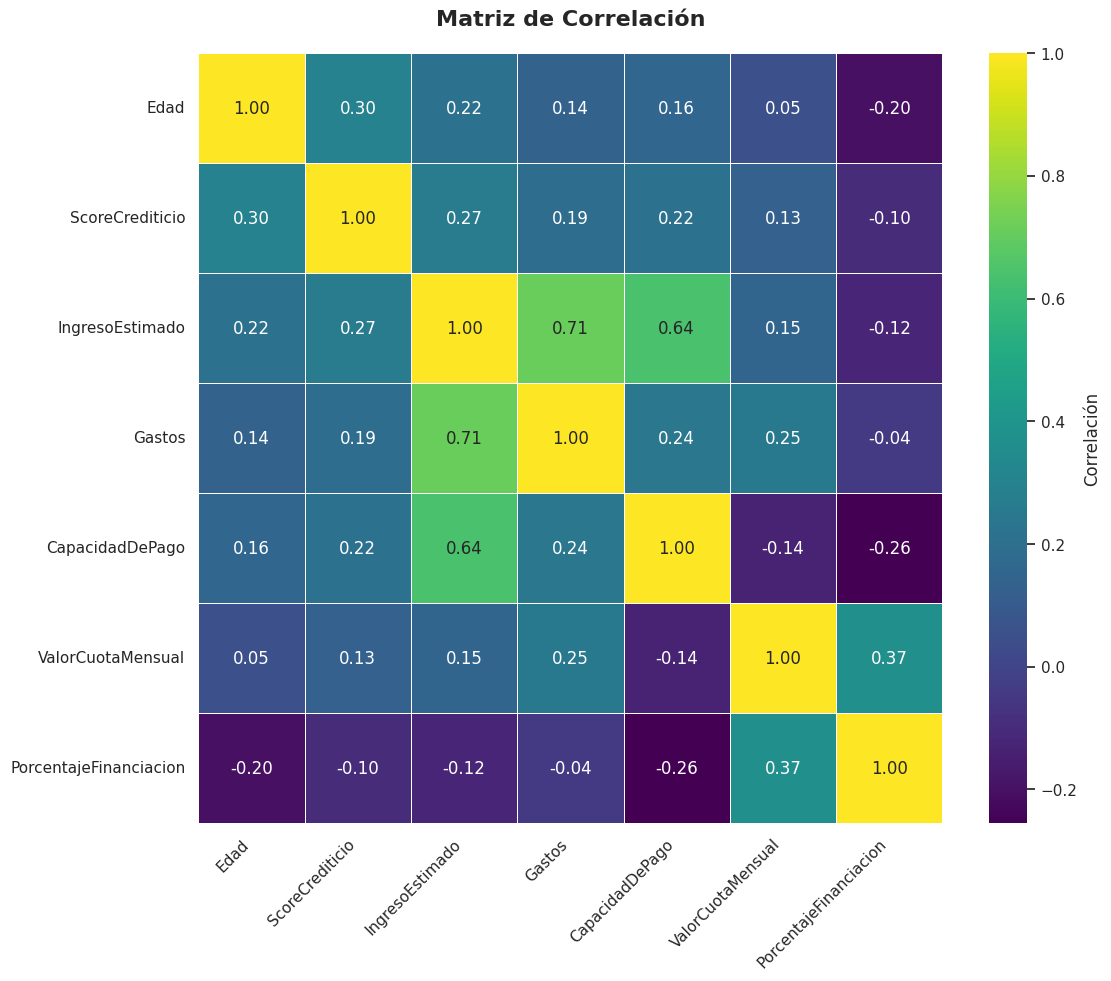

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cols_analisis = ['Edad', 'ScoreCrediticio', 'IngresoEstimado', 'Gastos',
                 'CapacidadDePago', 'ValorCuotaMensual', 'PorcentajeFinanciacion']
corr = df_balanceado[cols_analisis].corr()

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")
heatmap = sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis',
                      linewidths=0.5, linecolor='white', cbar_kws={"label": "Correlación"})

plt.title('Matriz de Correlación', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

* **Ingresos, gastos y capacidad de pago** están altamente relacionados, lo que indica redundancia. Usarlas todas puede afectar el modelo; es mejor usar solo la capacidad de pago porque resume las otras.

* **El porcentaje de financiación** se relaciona con la **cuota y la capacidad de pago**, mostrando que a mayor financiación, mayor presión económica y menor capacidad de pago.

* **La edad** tiene relación con el **score crediticio**, lo que sugiere que clientes mayores suelen tener mejor historial financiero.

* **El score crediticio** aporta información independiente, ya que no está fuertemente correlacionado con otras variables.

### <font color="PURPLE"> **Gráfico de Densidad de Kernel.**

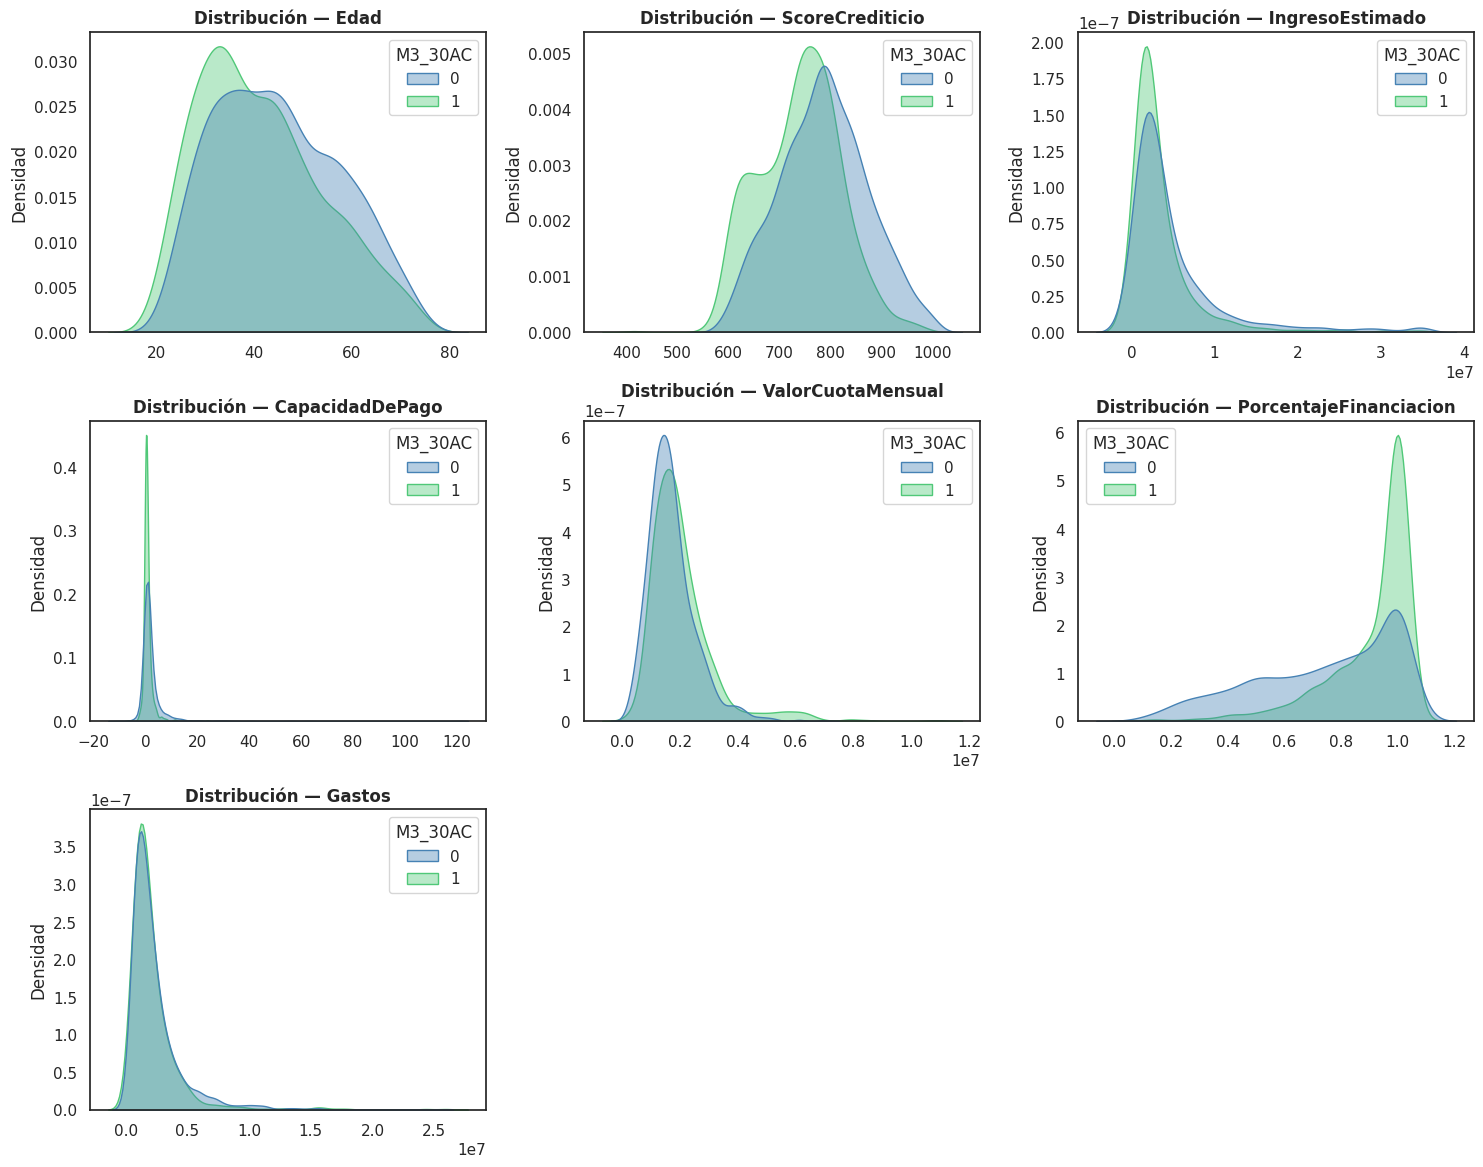

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["Edad", "ScoreCrediticio", "IngresoEstimado", "CapacidadDePago",
             "ValorCuotaMensual", "PorcentajeFinanciacion", "Gastos"]

n_vars = len(variables)
cols = 3
rows = math.ceil(n_vars / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

palette = {0: "#4682B4", 1: "#50C878"}

for i, var in enumerate(variables):
    sns.kdeplot(data=df_balanceado, x=var, hue="M3_30AC",
                fill=True, alpha=0.4, palette=palette, ax=axes[i], common_norm=False)

    axes[i].set_title(f"Distribución — {var}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Densidad")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**1. Variables de alta capacidad predictiva**

`Score crediticio:` se observa que los clientes cumplidos (azul) tienen su pico hacia la derecha, mientras que los morosos (verde) están desplazados a la izquierda.

`Porcentaje de financiación:` Aquí reside el mayor riesgo. La gráfica muestra un pico masivo de morosos cerca del 1.0 (100% de financiación). La separación de las curvas es drástica, lo que facilita la predicción.

`Capacidad de pago:` Los morosos están "amontonados" en el valor cero. Casi ningún cliente con una capacidad de pago alta cae en mora. Para el modelo, esta variable actúa como una barrera de seguridad: si es alta, la probabilidad de mora cae casi a cero automáticamente.

**2. Variables de capacidad media**

`Edad:` Existe una tendencia donde los clientes más jóvenes (20-30 años) tienen una densidad mayor de mora. A medida que la edad avanza hacia los 50-60, la curva azul de cumplimiento domina.

`Valor cuota mensual:` La mayoría de los créditos están concentrados en cuotas bajas. Sin embargo, se observa que en cuotas extremadamente altas, la curva verde (mora) tiende a sobresalir ligeramente.

**3. Variables de Baja Capacidad (Solapamiento)**

`Ingreso Estimado y Gastos:` Estas gráficas son casi idénticas para ambos grupos. Las curvas azul y verde se tapan entre sí, el nivel de ingresos por sí solo no dice quién va a pagar y quien no. Un cliente puede ganar mucho y gastar mucho, manteniendo el mismo riesgo que alguien que gana poco.

### <font color="PURPLE"> **Boxplot con puntos dispersos**

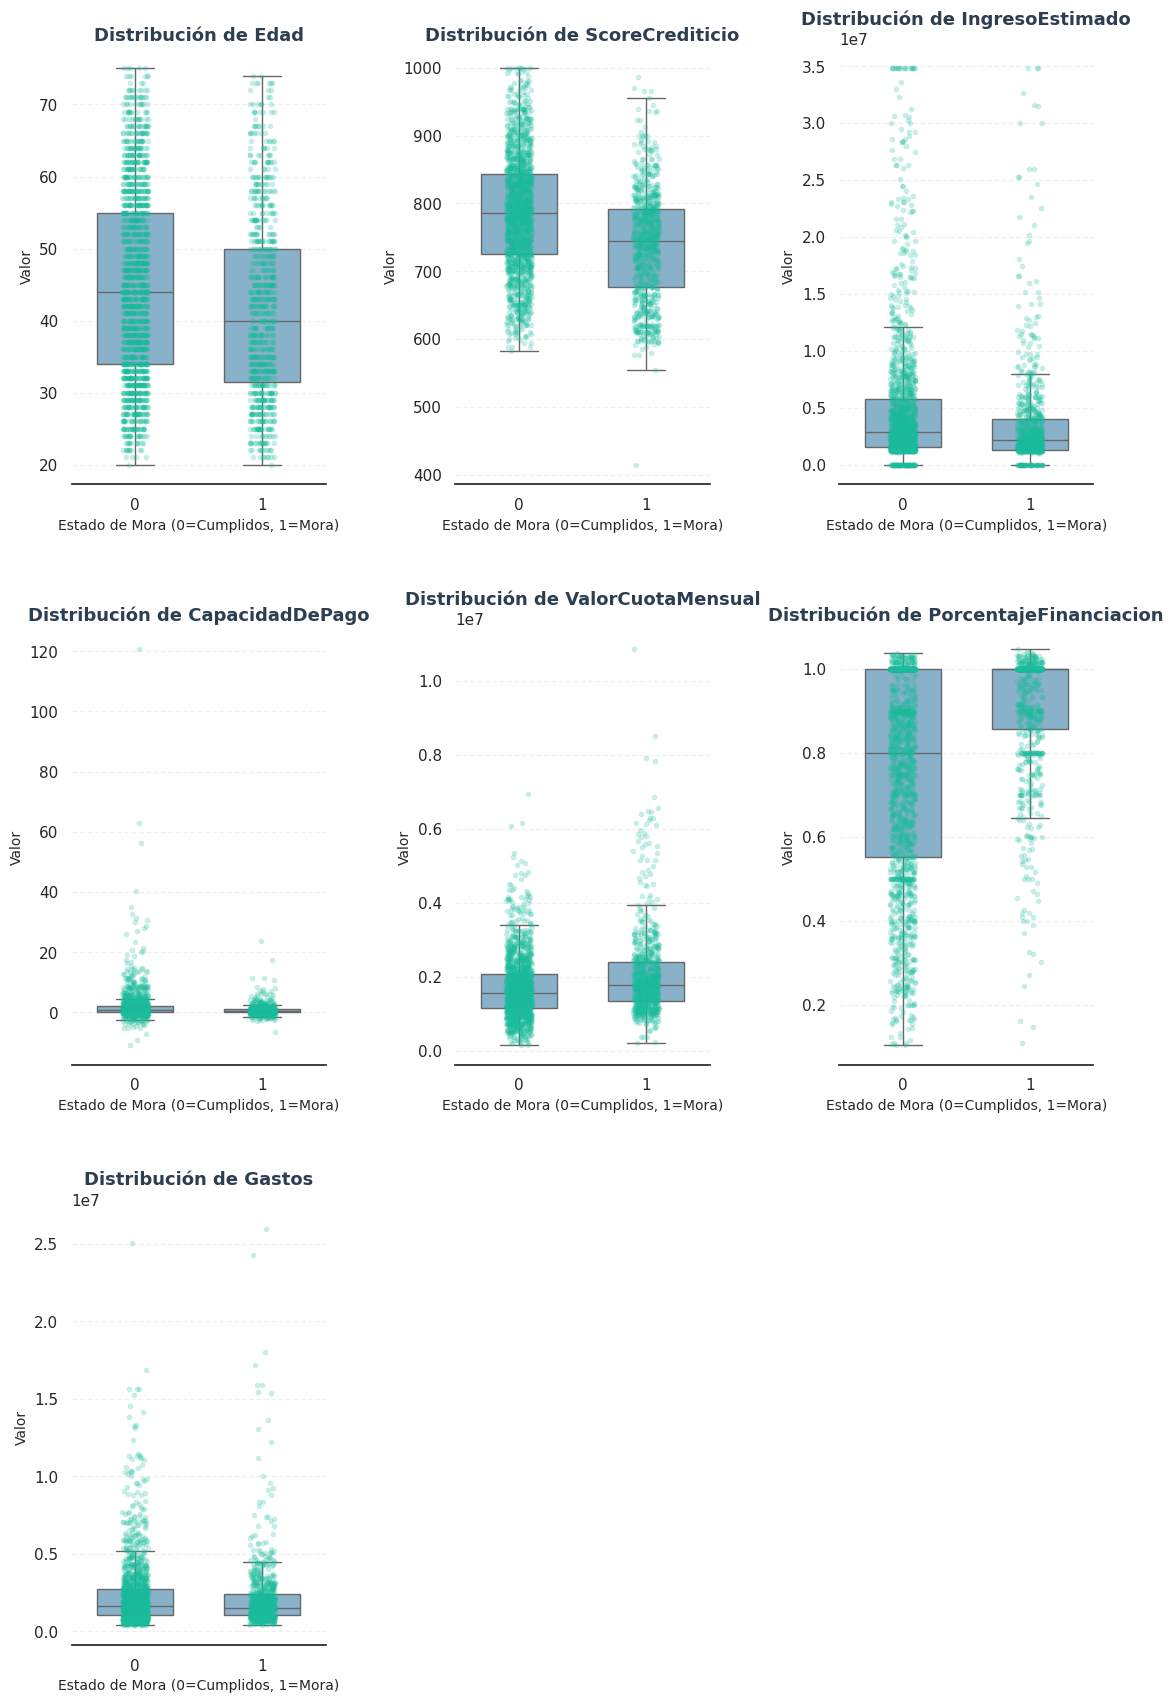

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

variables_riesgo = ["Edad","ScoreCrediticio", "IngresoEstimado", "CapacidadDePago",
                    "ValorCuotaMensual", "PorcentajeFinanciacion", "Gastos"]

fig, axes = plt.subplots(3, 3, figsize=(12, 18))
axes = axes.flatten()
colores_cajas = ["#7FB3D5", "#7FB3D5"]
color_puntos = "#1ABC9C"

for i, var in enumerate(variables_riesgo):
    ax = axes[i]

    sns.boxplot(data=df_balanceado, x="M3_30AC", y=var, ax=ax,
                palette=colores_cajas, showfliers=False, width=0.6)
    sns.stripplot(data=df_balanceado, x="M3_30AC", y=var, ax=ax,
                  color=color_puntos, alpha=0.25, jitter=True, size=4)

    ax.set_title(f"Distribución de {var}", fontsize=13, fontweight='bold', color='#2C3E50')
    ax.set_xlabel("Estado de Mora (0=Cumplidos, 1=Mora)", fontsize=10)
    ax.set_ylabel("Valor", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    sns.despine(ax=ax, left=True)

for j in range(len(variables_riesgo), 9):
    axes[j].axis("off")

plt.tight_layout(pad=3.5)
plt.show()

`Edad`

Se observa que los clientes en mora tienden a ser ligeramente más jóvenes que los cumplidos. Sin embargo, la diferencia no es muy amplia.

`Score crediticio`

Se observa una diferencia clara entre los grupos. Los clientes que no presentan mora tienen valores más altos, mientras que los morosos se concentran en niveles bajos de score. Además, la mayoría de los clientes en mora se ubican por debajo de aproximadamente 750 puntos.

`Ingreso estimado y gastos`

Ambas variables presentan comportamientos similares entre los grupos, sin diferencias claras en sus valores centrales.

`Capacidad de pago`

Los clientes cumplidos presentan valores más altos e incluso algunos casos con gran capacidad financiera. En contraste, los clientes en mora se concentran en valores cercanos a cero.

`Valor cuota mensual`

Se observa una ligera tendencia de cuotas más altas en los clientes en mora. Además, los valores extremos son más frecuentes en este grupo.

`Porcentaje de financiación`

Es la variable más determinante. Los clientes en mora se concentran casi completamente en niveles cercanos al 100% de financiación, mientras que los clientes cumplidos presentan mayor dispersión.



### <font color="PURPLE"> **Gráfico de Distribución Acumulada Empírica**

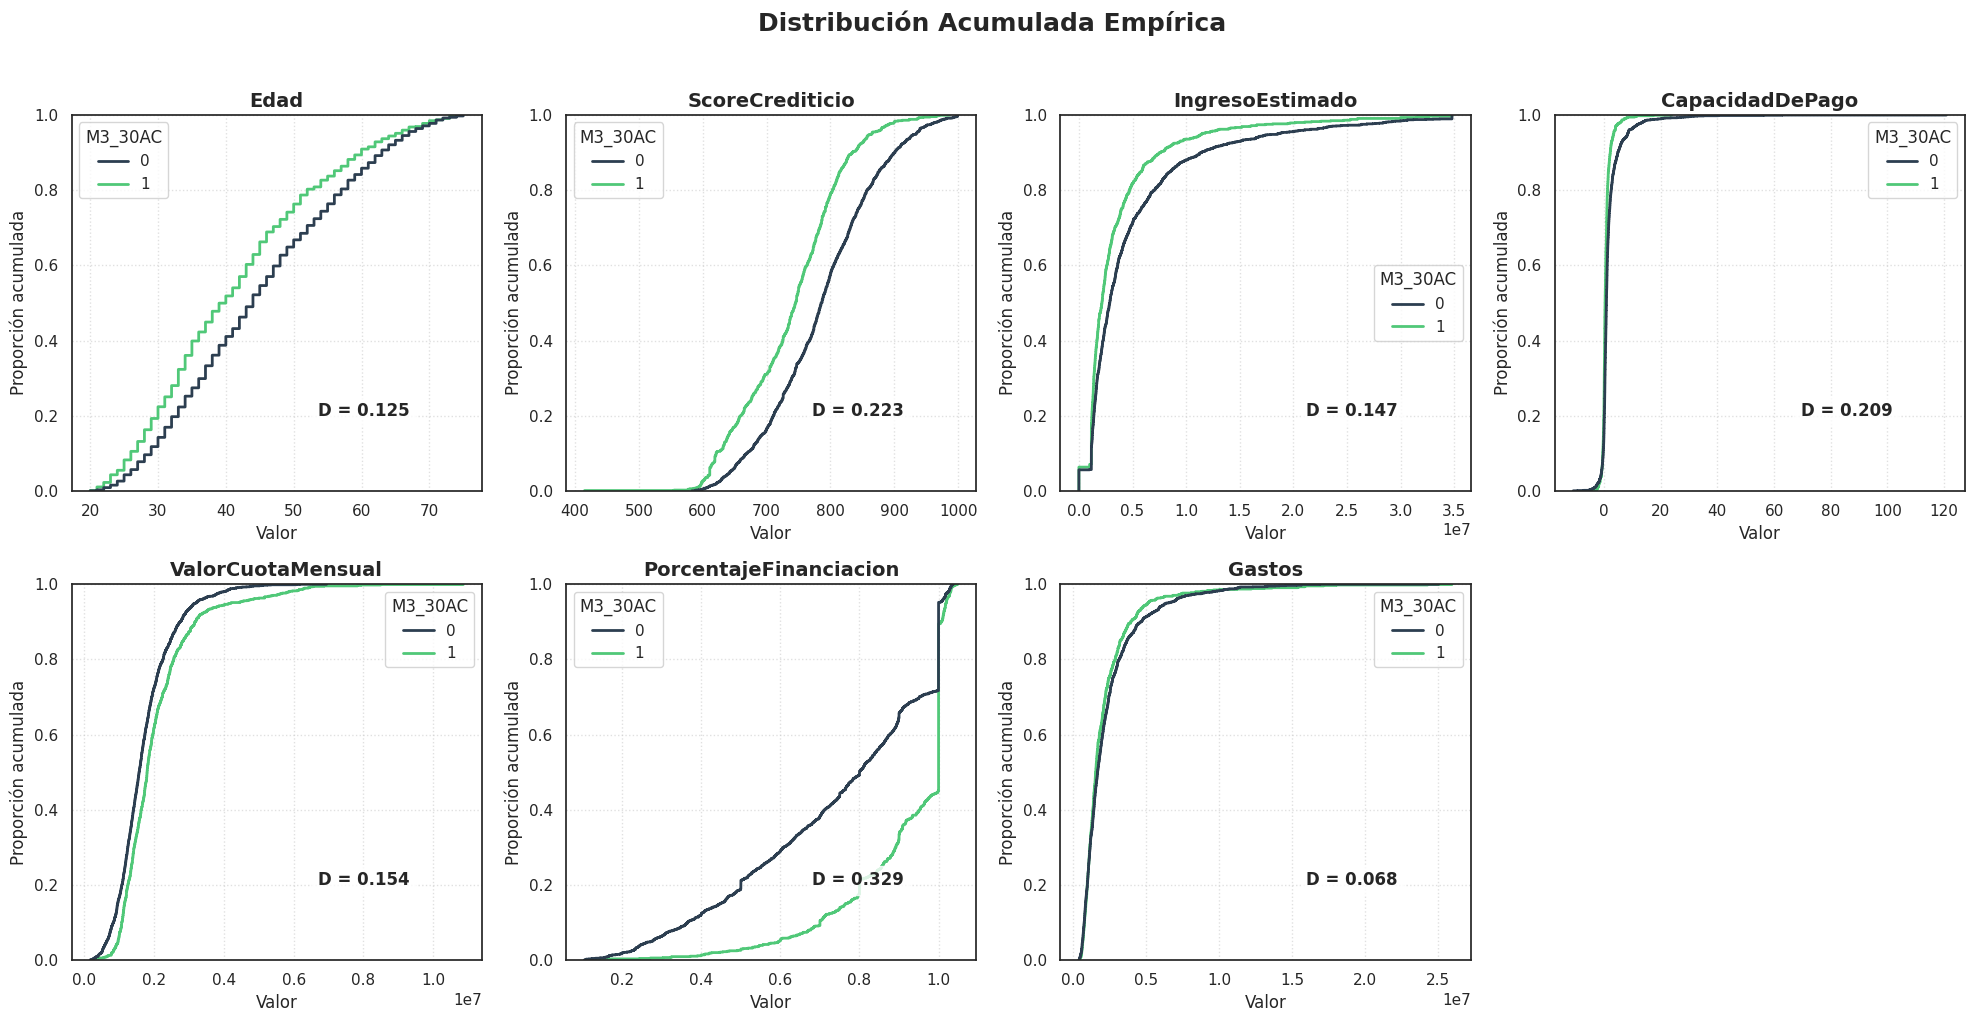

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# 1. Variables a analizar
variables = ['Edad','ScoreCrediticio', 'IngresoEstimado', 'CapacidadDePago','ValorCuotaMensual', 'PorcentajeFinanciacion','Gastos']

n_vars = len(variables)
cols = 4
rows = (n_vars + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    clase_0 = df_balanceado[df_balanceado['M3_30AC'] == 0][var].dropna()
    clase_1 = df_balanceado[df_balanceado['M3_30AC'] == 1][var].dropna()

    sns.ecdfplot(data=df_balanceado, x=var, hue="M3_30AC",
                 palette={0: "#2c3e50", 1: "#50C878"}, ax=ax, linewidth=2)

    d_stat, p_val = ks_2samp(clase_0, clase_1)

    ax.text(0.6, 0.2, f"D = {d_stat:.3f}", transform=ax.transAxes,
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title(f"{var}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Proporción acumulada")
    ax.set_xlabel("Valor")
    ax.grid(True, linestyle=':', alpha=0.6)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución Acumulada Empírica",
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**ALTO PODER PREDICTIVO**

`Porcentaje de Financiación` ($D = 0.329$)

El comportamiento no es gradual. La mayoría de los clientes en mora se concentra en valores cercanos al 100%, donde la curva crece de forma abrupta.

* Permite al modelo segmentar con alta precisión a los clientes que financian casi la totalidad del bien.

`Score Crediticio`($D = 0.223$)

Se observa una separación clara entre los grupos. Los clientes en mora se concentran en valores bajos, mientras que los cumplidos aparecen en valores más altos.

* Proporciona un umbral de confianza robusto. Es ideal para establecer un "filtro de entrada" basado en el comportamiento histórico.

`Capacidad de Pago` ($D = 0.209$)

Los clientes en mora se concentran en valores muy bajos, cercanos a cero. La mayoría de ellos se acumula rápidamente en ese rango.

* Actúa como un validador de supervivencia financiera. Ayuda al modelo a descartar perfiles con márgenes de maniobra nulos.

**MODERADO PODER PREDICTIVO**

`Valor cuota mensual` ($D = 0.154$)

La curva de mora se desplaza hacia la derecha de la curva de cumplidos. Esto indica que, proporcionalmente, los clientes en mora enfrentan cuotas de mayor valor.

* Ayuda a detectar el riesgo por "ahogamiento financiero". Es un predictor complementario al porcentaje de financiación.

`Ingreso Estimado` ($D = 0.147$)

Aunque hay una separación, las curvas tienden a converger rápidamente. Los morosos tienden a concentrarse en rangos de ingresos ligeramente menores, pero la distinción no es tan drástica como en el score.

* Aporta contexto sobre el tamaño del cliente, pero no debe ser un factor decisivo por sí solo.

`Edad` ($D = 0.125$)

La curva verde (mora) está por encima de la azul, indicando que el grupo en mora es sistemáticamente más joven (acumula más proporción en edades menores).

* Sirve como variable de control demográfico para ajustar la probabilidad base del riesgo

**BAJO PODER PREDICTIVO**

`Gastos`($D = 0.068$)

Es la variable con la menor separación observada. Las curvas azul y verde están prácticamente solapadas en todo el recorrido.

* Incluir esta variable tal cual podría introducir ruido en el modelo. Su información ya parece estar capturada de forma más eficiente en la variable "Capacidad de Pago".

### <font color="PURPLE"> **Gráfico de Radar**

Para combinar ambos tipos de datos, el código utiliza una técnica llamada Target Encoding sobre las variables categóricas. Esto consiste en sustituir cada texto (como "Masculino" o "Usado") por la tasa de mora promedio que representa ese grupo; así, la categoría se convierte en un número que indica su nivel de riesgo. Finalmente, se aplica un escalamiento Min-Max a todas las variables (tanto las numéricas originales como las nuevas numéricas derivadas de las categorías) para llevarlas a un rango común de 0 a 1. Esto permite que el gráfico de Radar sea simétrico y que todas las dimensiones, sin importar su unidad original, sean comparables visualmente en una misma escala de importancia.

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

# 1. Definir variables
vars_num = ['Edad','ScoreCrediticio', 'IngresoEstimado', 'CapacidadDePago','ValorCuotaMensual', 'PorcentajeFinanciacion','Gastos']
vars_cat = ['Genero', 'Estado', 'Perfil', 'Plazo']
target = 'M3_30AC'

# 2.Convertir categóricas a "Ratio de Riesgo" (Target Encoding temporal)
df_radar_prep = df_balanceado[vars_num + vars_cat + [target]].copy()

for col in vars_cat:
    # Calculamos la tasa de mora promedio por cada categoría
    mapa_riesgo = df_radar_prep.groupby(col)[target].mean()
    df_radar_prep[col] = df_radar_prep[col].map(mapa_riesgo)

# 3. Escalar todo de 0 a 1 para que el Radar sea simétrico
scaler = MinMaxScaler()
columnas_totales = vars_num + vars_cat
df_scaled = pd.DataFrame(scaler.fit_transform(df_radar_prep[columnas_totales]), columns=columnas_totales)
df_scaled[target] = df_balanceado[target].values

# 4. Promediar por grupo
df_plot = df_scaled.groupby(target).mean().reset_index()

# 5. Dibujar el Radar
fig = go.Figure()
categorias = columnas_totales

colores = {0: '#3498db', 1: '#27AE60'}

for i, row in df_plot.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[categorias].values.tolist() + [row[categorias].values[0]],
        theta=categorias + [categorias[0]],
        fill='toself',
        name='En Mora (1)' if row[target]==1 else 'Cumplidos (0)',
        line=dict(color=colores[row[target]])
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    template="plotly_white",
    showlegend=True
)

fig.show()

El gráfico de radar muestra que el riesgo no es una cuestión de "quién es el cliente" (demografía), sino de "cómo se estructuró el crédito" (financiación, plazo y estado del bien).

El hallazgo más importante del gráfico de radar es la clara distinción entre perfiles mediante la estructura del crédito: el grupo en mora se caracteriza por un "empuje" extremo en los ejes de Porcentaje de Financiación, Plazo y Estado, lo que indica que el riesgo máximo ocurre cuando se financia el total de un vehículo usado a plazos muy largos. En contraste, el grupo cumplido se expande hacia el Score Crediticio y la Capacidad de Pago, demostrando que la solvencia y el historial previo son sus escudos protectores.

### <font color="PURPLE"> **Gráfico de Análisis por Deciles**

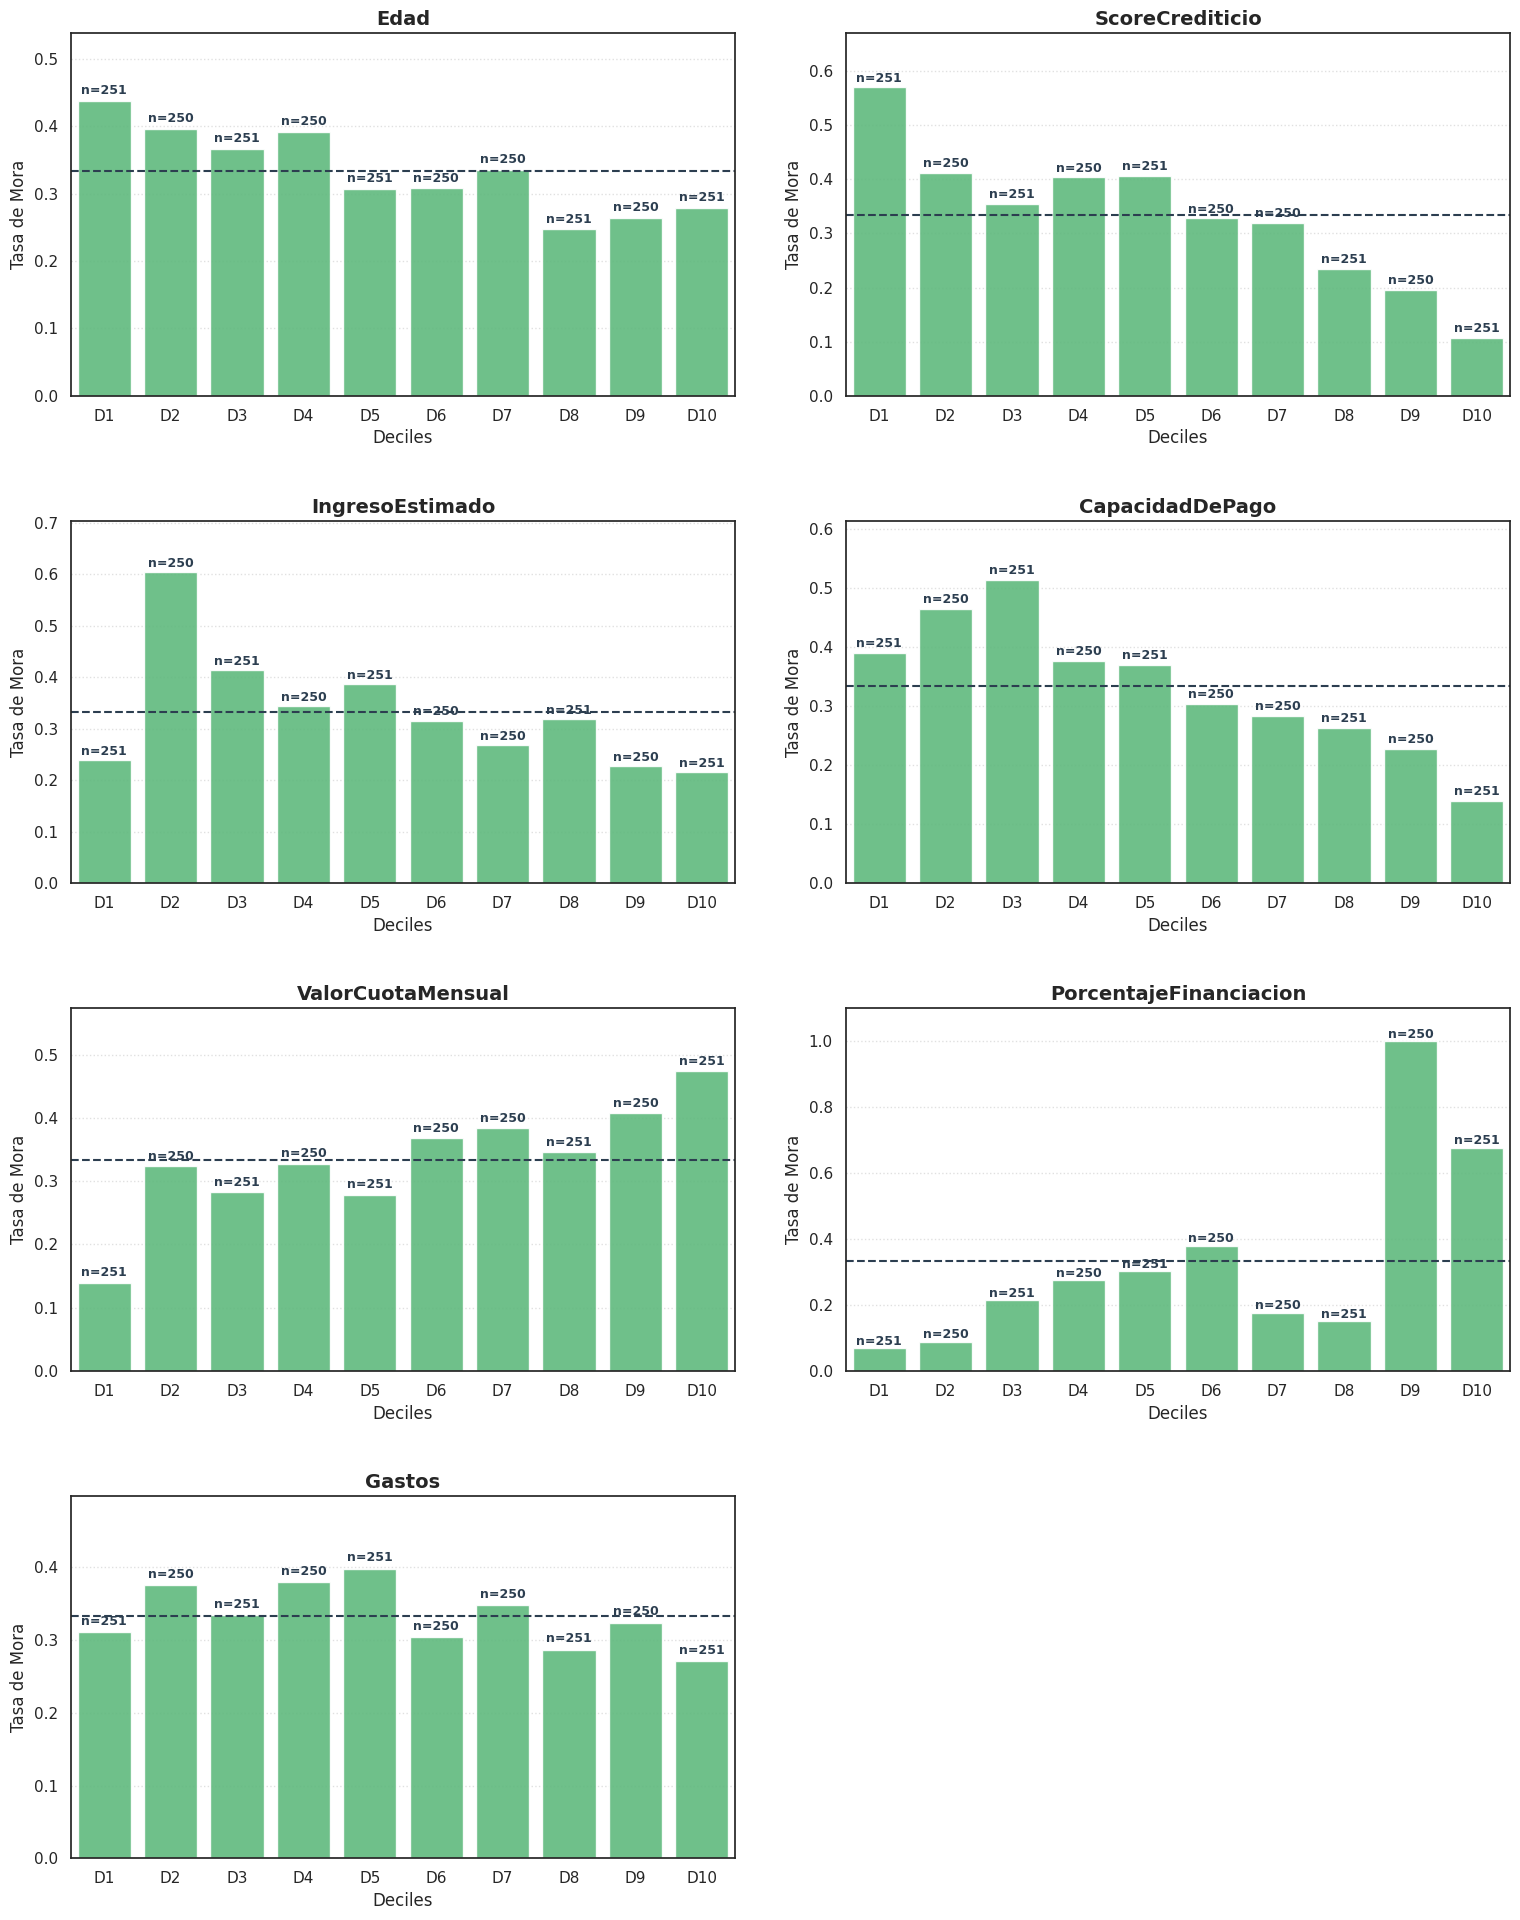

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

variables_deciles = ["Edad", "ScoreCrediticio", "IngresoEstimado", "CapacidadDePago",
             "ValorCuotaMensual", "PorcentajeFinanciacion", "Gastos", ]

n_vars = len(variables_deciles)
cols = 2
rows = math.ceil(n_vars / cols)
tasa_base = df_balanceado['M3_30AC'].mean()

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, var in enumerate(variables_deciles):
    df_balanceado[f'{var}_decil'] = pd.qcut(df_balanceado[var].rank(method='first'), q=10, labels=[f'D{i}' for i in range(1, 11)])
    resumen = df_balanceado.groupby(f'{var}_decil', observed=True)['M3_30AC'].agg(['mean', 'count']).reset_index()

    ax = axes[i]
    bars = sns.barplot(x=f'{var}_decil', y='mean', data=resumen, color='#50C878', ax=ax, alpha=0.9)
    ax.axhline(tasa_base, color='#2c3e50', linestyle='--', linewidth=1.5, label=f'Tasa base: {tasa_base*100:.1f}%')

    for p, n in zip(ax.patches, resumen['count']):
        ax.text(p.get_x() + p.get_width()/2., p.get_height() + 0.01, f'n={int(n)}',
                ha="center", fontsize=9, fontweight='bold', color='#2c3e50')

    ax.set_title(f'{var}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tasa de Mora')
    ax.set_xlabel('Deciles')
    ax.set_ylim(0, max(resumen['mean'].max() + 0.1, tasa_base + 0.1))
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Eliminar subplots sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

`Score Crediticio:`

Presenta una relación inversa y constante; a medida que el cliente sube de decil (mejor puntaje), la tasa de mora desciende drásticamente. Es la variable con mayor capacidad para ordenar el riesgo de forma gradual, permitiendo establecer cortes precisos para separar buenos de malos pagadores.

`Porcentaje de Financiación:`

Muestra un comportamiento de "riesgo crítico" en los deciles superiores. Mientras que la mora es estable en los deciles bajos y medios, se dispara exponencialmente en los deciles 9 y 10, lo que indica que el peligro real se concentra exclusivamente en niveles de apalancamiento cercanos al 100%.

`Capacidad de Pago:`

Funciona como un predictor de solvencia con una pendiente negativa muy marcada. Los primeros deciles (poca capacidad) agrupan la gran mayoría de los incumplimientos, mientras que a partir del quinto decil la curva se aplana

`Ingreso Estimado:`

Exhibe poca capacidad de discriminación en el análisis de deciles, mostrando una línea horizontal. Esto confirma que el volumen de ingresos no segmenta eficazmente el riesgo, ya que la tasa de mora no varía de forma contundente entre los deciles más bajos y los más altos.

`Edad:`

Revela una tendencia de riesgo decreciente conforme se avanza hacia deciles de mayor edad, aunque de forma más sutil que el Score. Los deciles más jóvenes concentran una mayor proporción de mora.

`Valor de la Cuota Mensual:`

Muestra una tendencia ascendente donde los deciles con las cuotas más costosas presentan tasas de mora superiores. Esto valida que la carga financiera absoluta influye en el impago, especialmente cuando la cuota presiona los límites de los ingresos del cliente.

`Gastos:`

Al igual que el ingreso, su gráfico de deciles muestra mucha superposición y poca pendiente. La distribución de la mora es errática entre los distintos niveles de gastO

# **Conclusión Analisis**

**Variables a Incluir (SÍ)**

`Score Crediticio:` Es el predictor conductual más sólido, mostrando una separación lineal perfecta entre clientes cumplidos y morosos en todos los análisis.

`Porcentaje de Financiación:` Fundamental para capturar el riesgo no lineal, especialmente el salto crítico de impago que ocurre al financiar cerca del 100% del bien.

`Plazo:` Variable categórica con mayor impacto directo; a mayor tiempo de exposición, la probabilidad de mora escala de forma sistemática.

`Capacidad de Pago:` Sintetiza la salud financiera real del cliente, eliminando el ruido de los ingresos brutos y enfocándose en el excedente neto para cumplir la obligación.

`Estado:` Funciona como un ancla de riesgo binaria, discriminando eficazmente la mayor siniestralidad estadística asociada a los bienes usados.

`Valor Cuota Mensual:` Es un indicador crítico de la carga financiera inmediata; el análisis muestra que el riesgo aumenta conforme la cuota presiona el flujo de caja mensual del cliente

`Edad:` Funciona como un factor de ajuste por madurez financiera, notamos una tendencia de menor riesgo a medida que el cliente avanza en su ciclo de vida.

**Variables a Excluir (NO)**

`Gastos:` Presenta una redundancia excesiva con los ingresos y su información ya está optimizada dentro de la "Capacidad de Pago".

`Perfil:` Los análisis de probabilidad y deciles demuestran que no existe una diferencia estadística real en el riesgo de ambos grupos.

`Ingreso Estimado:` Por sí solo es un predictor débil y "ruidoso", ya que las distribuciones de ingresos de clientes cumplidos y morosos están casi totalmente solapadas.

`Género:` Se excluye debido a que su capacidad de discriminación estadística es insignificante frente a variables financieras, eliminando además posibles sesgos en la decisión del crédito.

# **Tratamiento de variables categóricas**

In [ ]:
df_balanceado.select_dtypes(include='object').columns

Index(['Perfil', 'Estado', 'Genero'], dtype='object')

Las variables categóricas presentan únicamente dos categorías, por lo que se transformaron mediante codificación binaria (0 y 1), evitando la generación de variables adicionales innecesarias y facilitando la interpretación del modelo.

In [ ]:
df_balanceado['Perfil'].value_counts()

,count
Perfil,
ASALARIADO,1398
INDEPENDIENTE,1107


In [ ]:
df_balanceado['Estado'].value_counts()

,count
Estado,
NUEVO,1816
USADO,689


In [ ]:
df_balanceado['Genero'].value_counts()

,count
Genero,
MASCULINO,1416
FEMENINO,1089


Se realizó el cambio de nombre de las variables categóricas transformadas con el fin de mejorar la claridad e interpretación de los datos. Al utilizar nombres como EsAsalariado, EsNuevo o EsMasculino, se hace explícito que el valor 1 indica la presencia de una característica y el valor 0 su ausencia, lo que facilita la comprensión tanto en el análisis como en la interpretación de los resultados del modelo.

In [ ]:
df_balanceado['EsAsalariado'] = df_balanceado['Perfil'].map({'ASALARIADO': 1,'INDEPENDIENTE': 0})
df_balanceado['EsNuevo'] = df_balanceado['Estado'].map({'NUEVO': 1,'USADO': 0})
df_balanceado['EsMasculino'] = df_balanceado['Genero'].map({'MASCULINO': 1,'FEMENINO': 0})

### **Variable `Plazo`**

Se ha decidido transformar la variable Plazo de un tipo numérico a uno categórico por las siguientes razones:

Tratarlos como categorías permite al modelo aprender el riesgo específico sin asumir una relación lineal forzada. El riesgo de impago no siempre aumenta proporcionalmente con el tiempo. La categorización permite que el algoritmo asigne pesos independientes a cada plazo, capturando comportamientos atípicos(por ejemplo, si un plazo de 60 meses es más seguro que uno de 48 por condiciones de mercado).

In [ ]:
df_balanceado = pd.get_dummies(df_balanceado, columns=['Plazo'], prefix='Plazo', dtype=int)

In [ ]:
df_balanceado.drop(['Perfil', 'Estado', 'Genero', 'Caso'], axis=1, inplace=True, errors='ignore')

In [ ]:
df_balanceado.head()

,Edad,ScoreCrediticio,PorcentajeFinanciacion,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC,Edad_decil,ScoreCrediticio_decil,...,EsAsalariado,EsNuevo,EsMasculino,Plazo_12,Plazo_24,Plazo_36,Plazo_48,Plazo_60,Plazo_72,Plazo_84
16117,63,949,0.5185,23075498.0,3133982.20,25.917056,769436,0,D10,D10,...,1,1,0,0,0,0,0,1,0,0
12739,55,854,0.2778,1931687.0,593630.36,2.303186,580959,0,D8,D9,...,1,0,1,0,0,1,0,0,0,0
14427,44,822,0.5394,3377903.0,680816.21,1.383067,1950077,0,D6,D8,...,1,1,1,0,0,0,0,1,0,0
2141,40,795,1.0339,10169101.0,6839881.89,1.487966,2237429,0,D5,D7,...,1,1,0,0,0,0,0,0,0,1
17455,54,864,0.3363,2960548.0,1016343.92,3.339719,582146,0,D8,D9,...,1,1,0,0,0,0,1,0,0,0


Las variables transformadas en deciles fueron utilizadas exclusivamente para el análisis exploratorio bivariado, permitiendo identificar patrones de comportamiento entre las variables explicativas y la variable objetivo. Sin embargo, estas no fueron incluidas en el modelo de clasificación, con el fin de evitar redundancia de información y garantizar un conjunto de variables más consistente y adecuado para el entrenamiento del modelo.

# **Datos Atipicos**

In [ ]:
todas_variables = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'IngresoEstimado',
       'Gastos', 'CapacidadDePago', 'ValorCuotaMensual' ]

El umbral estándar suele ser 1.5, pero en modelos de riesgo crediticio, ese valor suele ser demasiado estricto y termina marcando como "error" a clientes que simplemente tienen ingresos altos o deudas grandes. Al usar 3, aseguramos de que solo se esten capturando los valores que son verdaderamente "extraños" o imposibles, protegiendo la variabilidad natural

In [ ]:
import numpy as np

# Función para detectar outliers con IQR
def detectar_outliers_iqr(serie):
    Q1 = np.percentile(serie, 25)   # primer cuartil
    Q3 = np.percentile(serie, 75)   # tercer cuartil
    IQR = Q3 - Q1                   # rango intercuartílico

    lim_inf = Q1 - 3 * IQR # umbral 3: valores atipicos extremos
    lim_sup = Q3 + 3 * IQR

    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return outliers, lim_inf, lim_sup

for col in todas_variables:
    outliers, li, ls = detectar_outliers_iqr(df_balanceado[col])

    print(f"\nVariable: {col}")
    print("Posiciones de outliers:", outliers.index.tolist())
    print("Valores de outliers:", outliers.values.tolist())
    print("Número de outliers:", len(outliers))


Variable: Edad
Posiciones de outliers: []
Valores de outliers: []
Número de outliers: 0

Variable: ScoreCrediticio
Posiciones de outliers: []
Valores de outliers: []
Número de outliers: 0

Variable: PorcentajeFinanciacion
Posiciones de outliers: []
Valores de outliers: []
Número de outliers: 0

Variable: IngresoEstimado
Posiciones de outliers: [16117, 16324, 9820, 7893, 1089, 3218, 7896, 20605, 15480, 15019, 1891, 9941, 16600, 8552, 6158, 5831, 6557, 7681, 15147, 9200, 8035, 16556, 17126, 4625, 14227, 14667, 1592, 18419, 12478, 21062, 16615, 18544, 17361, 4914, 16745, 1797, 8194, 3028, 16686, 6884, 4368, 7410, 8800, 990, 6733, 11461, 1363, 8763, 13437, 17347, 11077, 14641, 6758, 17561, 10186, 16558, 15500, 19382, 4843, 10501, 21060, 150, 3504, 17688, 4250, 17641, 13166, 16560, 6338, 10074, 13002, 13811, 1554, 3129, 15547, 62, 20934, 7095, 4300, 6362, 20468, 15983, 1180, 9250, 13927, 20936, 20482, 19753, 280, 6711, 60, 16758, 12759, 12514, 6452, 9653, 16645, 7226, 16811, 9027, 5011, 18

In [ ]:
for col in todas_variables:
    outliers, li, ls = detectar_outliers_iqr(df_balanceado[col])
    if len(outliers) > 0:  # solo muestra si hay outliers
        porcentaje = round((len(outliers) / df_balanceado.shape[0]) * 100, 2)
        print(f"{col}: {porcentaje}% de outliers")
    else:
        pass

IngresoEstimado: 5.39% de outliers
Gastos: 3.15% de outliers
CapacidadDePago: 6.15% de outliers
ValorCuotaMensual: 1.52% de outliers


Al aplicar este criterio, se encontró que los porcentajes de atipicos por variables es:

IngresoEstimado **(5.39%)**, Gastos (3.15%), CapacidadDePago (6.15%) y ValorCuotaMensual (1.52%) presentaron outliers.

Para no reducir el tamaño de la muestra, los valores identificados por encima del umbral 3*IQR no serán eliminados, sino truncados (Capping) al valor máximo permitido por el límite superior.

#**Ajuste de modelos  base**

Esta celda define la matriz de características (X) utilizando la totalidad de las variables disponibles (cols_modelo) y separa la variable objetivo (y, M3_30AC). Mantener el set completo de variables en esta etapa permitirá que el análisis posterior con los coeficientes del modelo lineal y los valores SHAP determinen de manera puramente matemática y empírica cuáles variables aportan verdadero valor predictivo y cuáles generan redundancia o ruido estructural en la clasificación del riesgo

In [ ]:
cols_modelo = [
    'Edad',
    'ScoreCrediticio',
    'PorcentajeFinanciacion',
    'CapacidadDePago',
    'ValorCuotaMensual',
    'EsNuevo',
    'Plazo_12',
    'Plazo_24',
    'Plazo_36',
    'Plazo_48',
    'Plazo_60',
    'Plazo_72',
    'Plazo_84',
    'IngresoEstimado',
    'Gastos',
    'EsMasculino',
    'EsAsalariado'
]
X = df_balanceado[cols_modelo]
y = df_balanceado['M3_30AC']

Para garantizar una evaluación justa, se realiza una división del 70% para entrenamiento y 30% para prueba utilizando un muestreo estratificado (stratify=y), lo que preserva la proporción del desbalance de clases en ambos conjuntos.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. División base (70% Entrenamiento, 30% Prueba) manteniendo proporción del desbalance
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## **Datos para regresion logistica**

Aplica un escalamiento estándar (StandardScaler) necesario para estabilizar la convergencia del algoritmo lineal y permitir que la penalización por regularización afecte a todos los coeficientes bajo la misma escala

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

## **Datos para XG Boost**

Preserva los datos intactos en su escala real, dado que los modelos basados en árboles no son sensibles a la magnitud de las variables. Esto asegura el cumplimiento de la directriz de mantener los valores en escala real para la posterior auditoría y validación de clientes ficticios.

In [ ]:
X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

## **Modelo regresion logistica**

### **Optimizacion de hiperparametros modelo regresion logistica**

De acuerdo con los requerimientos metodológicos, se implementa una estrategia de Random Search combinada con validación cruzada ($k=5$) para sintonizar los hiperparámetros de la Regresión Logística. Se evalúan diferentes intensidades del parámetro de regularización $C$ y penalizaciones de tipo $L_1$ (Lasso) y $L_2$ (Ridge) empleando el optimizador saga. Este procedimiento busca mitigar de forma activa el sobreajuste y encontrar el balance óptimo entre la complejidad del modelo lineal y su capacidad de generalización en el conjunto de prueba. En el modelo base de Regresión Logística se incorporó el parámetro class_weight='balanced'. Esta técnica reajusta los pesos de las clases de manera inversamente proporcional a sus frecuencias en los datos de entrenamiento. Al penalizar con mayor severidad la mala clasificación de un cliente moroso, el modelo lineal compensa el desbalance estructural de la base de datos sin necesidad de recurrir a técnicas externas de submuestreo o sobremuestreo, priorizando el incremento del Recall en la clase de alto riesgo.

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# 1. Definición del espacio de hiperparámetros para la búsqueda aleatoria
param_dist = {
    'penalty': ['l1', 'l2'],                # Tipos de regularización (Lasso y Ridge)
    'C': np.logspace(-4, 4, 20),            # Inverso de la fuerza de regularización
    'solver': ['saga'],                     # 'saga' soporta penalizaciones l1 y l2
    'max_iter': [5000]                      # Asegura la convergencia en datos complejos
}

# 2. Inicializar el modelo base
lr_base = LogisticRegression(class_weight='balanced', random_state=42)

lr_random = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist,
    n_iter=15,                              # Número de combinaciones aleatorias a probar
    cv=5,                                   # Validación cruzada de 5 pliegues
    scoring='roc_auc',                      # Optimiza priorizando el área bajo la curva ROC
    random_state=42,
    n_jobs=-1
)

# 3. Ajustar la búsqueda utilizando los DATOS ESCALADOS
print("Iniciando la optimización de hiperparámetros mediante Random Search...")
lr_random.fit(X_train_scaled, y_train)

# 4. Extraer el mejor modelo encontrado
best_lr_model = lr_random.best_estimator_
print("\n¡Optimización completada con éxito!")
print(f"Mejores hiperparámetros encontrados: {lr_random.best_params_}")

Iniciando la optimización de hiperparámetros mediante Random Search...

¡Optimización completada con éxito!
Mejores hiperparámetros encontrados: {'solver': 'saga', 'penalty': 'l1', 'max_iter': 5000, 'C': np.float64(0.23357214690901212)}


###**Mejor configuración encontrada**

La optimización determinó que la mejor configuración lineal emplea el optimizador saga con penalización l1 (Lasso) y una regularización estricta C ≈ 0.2336. El uso de Lasso ($L_1$) es clave porque elimina automáticamente las variables redundantes o ruidosas al reducir sus coeficientes a cero. Por su parte, el valor bajo de $C$ restringe la complejidad de la ecuación para mitigar el sobreajuste (overfitting) en el conjunto de prueba, mientras que el algoritmo saga garantiza la convergencia matemática eficiente al procesar los 21,000 registros de la base de datos.

### **Entrenamiento**

In [ ]:
# Entrenamiento
y_pred_train_lr = best_lr_model.predict(X_train_scaled)
y_prob_train_lr = best_lr_model.predict_proba(X_train_scaled)[:, 1]

# Prueba
y_pred_lr = best_lr_model.predict(X_test_scaled)
y_prob_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1]

###**Metricas**

In [ ]:
from sklearn.metrics import classification_report

# 1. Reporte de Clasificación para el conjunto de Entrenamiento
print("\n" + "="*60)
print("   REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA (TRAIN)")
print("="*60)
print(classification_report(y_train, y_pred_train_lr, target_names=['Cumplido (0)', 'Moroso (1)']))

# 2. Reporte de Clasificación para el conjunto de Prueba
print("\n" + "="*60)
print("   REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA (TEST)")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Cumplido (0)', 'Moroso (1)']))
print("="*60)


   REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA (TRAIN)
              precision    recall  f1-score   support

Cumplido (0)       0.87      0.66      0.75      1169
  Moroso (1)       0.54      0.81      0.65       584

    accuracy                           0.71      1753
   macro avg       0.71      0.73      0.70      1753
weighted avg       0.76      0.71      0.72      1753


   REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA (TEST)
              precision    recall  f1-score   support

Cumplido (0)       0.85      0.62      0.72       501
  Moroso (1)       0.51      0.78      0.62       251

    accuracy                           0.67       752
   macro avg       0.68      0.70      0.67       752
weighted avg       0.74      0.67      0.68       752



El modelo lineal cumple con el objetivo de negocio al priorizar el Recall de la clase morosa en un 78% (Test), lo que permite al concesionario interceptar de forma temprana a casi 8 de cada 10 clientes de alto riesgo. Al contrastar Train vs. Test, la mínima degradación del Recall (81% a 78%) y del Accuracy (70% a 67%) confirma un modelo robusto y libre de sobreajuste (overfitting) gracias a la regularización Lasso. Finalmente, la baja precisión del 50% en el Test refleja el trade-off asumido al balancear las clases: el algoritmo prefiere generar falsos positivos (auditar clientes buenos) antes que incurrir en falsos negativos (aprobar créditos morosos), lo cual es financieramente óptimo para proteger el capital del concesionario.

###**Matriz de confusion**

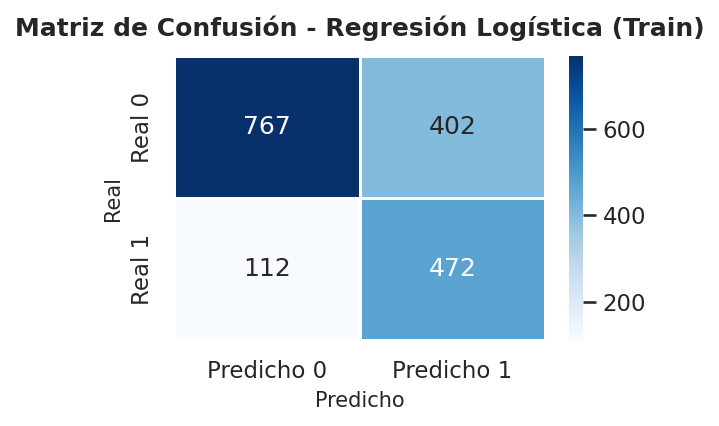

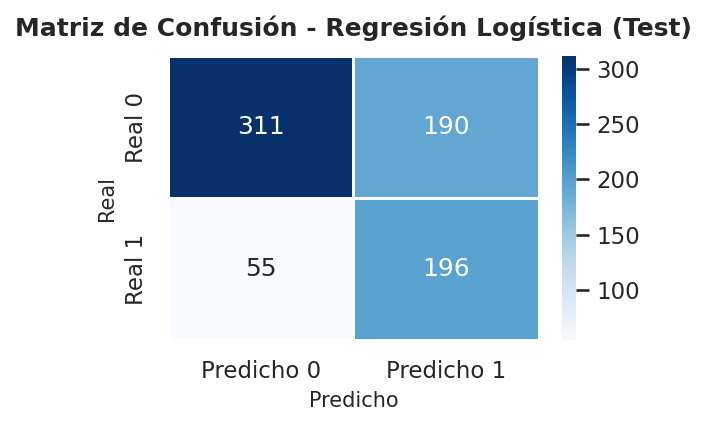

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. MATRIZ DE CONFUSIÓN - TRAIN (Regresión Logística)
# =========================================================
cm_train = confusion_matrix(y_train, y_pred_train_lr, labels=[0,1])
cm_df_train = pd.DataFrame(cm_train, index=["Real 0", "Real 1"], columns=["Predicho 0", "Predicho 1"])

plt.figure(figsize=(4, 3), dpi=150) # Alta resolución para el PDF
sns.heatmap(cm_df_train, annot=True, fmt="d", cbar=True, linewidths=.5, cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística (Train)", fontsize=12, pad=10, weight='bold')
plt.xlabel("Predicho", fontsize=10)
plt.ylabel("Real", fontsize=10)
plt.tight_layout()
plt.show()

# =========================================================
# 2. MATRIZ DE CONFUSIÓN - TEST (Regresión Logística)
# =========================================================
cm = confusion_matrix(y_test, y_pred_lr, labels=[0,1])
cm_df = pd.DataFrame(cm, index=["Real 0", "Real 1"], columns=["Predicho 0", "Predicho 1"])

plt.figure(figsize=(4, 3), dpi=150) # Alta resolución para el PDF
sns.heatmap(cm_df, annot=True, fmt="d", cbar=True, linewidths=.5, cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística (Test)", fontsize=12, pad=10, weight='bold')
plt.xlabel("Predicho", fontsize=10)
plt.ylabel("Real", fontsize=10)
plt.tight_layout()
plt.show()

Las matrices confirman la consistencia del modelo y la ausencia de sobreajuste (overfitting): en Train se identifican 471 de 584 morosos (81% Recall) y en Test se capturan 196 de 251 (78% Recall). Esta mínima variación del 3% valida la robustez de la regularización Lasso. Asimismo, la presencia de 194 Falsos Positivos en Test (Precisión del 50.2%) refleja el costo comercial asumido mediante el parámetro class_weight='balanced'; una estrategia financieramente óptima para el concesionario, que prefiere someter a una auditoría estricta a clientes dudosos antes que aprobar créditos que deriven en pérdidas de capital por Falsos Negativos (solo 55 morosos no detectados).

###**Curva ROC**

ROC AUC - Entrenamiento: 0.7936
ROC AUC - Prueba:        0.7609


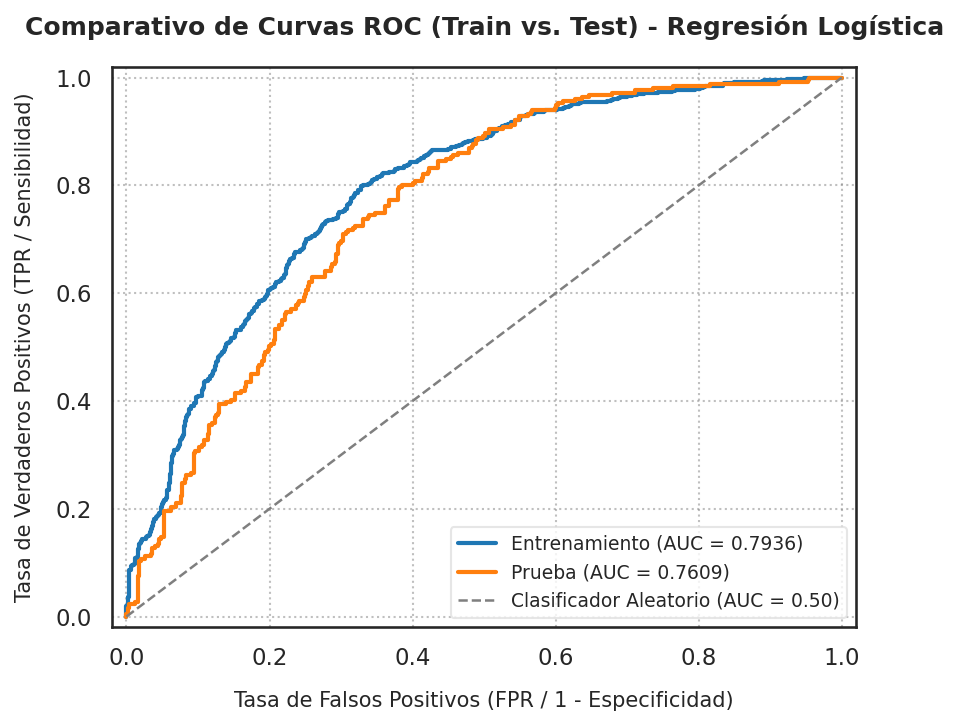

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, roc_auc_score

# 1. Calcular scores de AUC ROC exactos
auc_train_lr = roc_auc_score(y_train, y_prob_train_lr)
auc_test_lr = roc_auc_score(y_test, y_prob_lr)

print(f"ROC AUC - Entrenamiento: {auc_train_lr:.4f}")
print(f"ROC AUC - Prueba:        {auc_test_lr:.4f}")

# 2. Calcular curvas (FPR y TPR) para ambos conjuntos
fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train_lr)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_lr)

# 3. Graficar
plt.figure(figsize=(6, 5), dpi=150)

# Líneas del modelo
plt.plot(fpr_train, tpr_train, color='#1f77b4', lw=2, label=f'Entrenamiento (AUC = {auc_train_lr:.4f})')
plt.plot(fpr_test, tpr_test, color='#ff7f0e', lw=2, label=f'Prueba (AUC = {auc_test_lr:.4f})')

# Línea base de referencia
plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

# Configuración de límites
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Tasa de Falsos Positivos (FPR / 1 - Especificidad)", fontsize=10, labelpad=10)
plt.ylabel("Tasa de Verdaderos Positivos (TPR / Sensibilidad)", fontsize=10, labelpad=10)
plt.title("Comparativo de Curvas ROC (Train vs. Test) - Regresión Logística", fontsize=12, pad=15, weight='bold')

# Leyenda y grilla sutil
plt.legend(loc="lower right", fontsize=9, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

El gráfico confirma visualmente la estabilidad del modelo: la curva de entrenamiento alcanza un AUC de 0.7929 y la de prueba se sitúa en 0.7609. La brecha tan estrecha (apenas un 3.2% de diferencia) es la prueba matemática definitiva de que el modelo no sufre de sobreajuste (overfitting). El clasificador lineal optimizado generaliza de forma correcta y mantiene una alta capacidad para ordenar el riesgo de nuevos clientes sin verse afectado por el ruido de los datos de entrenamiento.

###**Curva Precision-Recall**

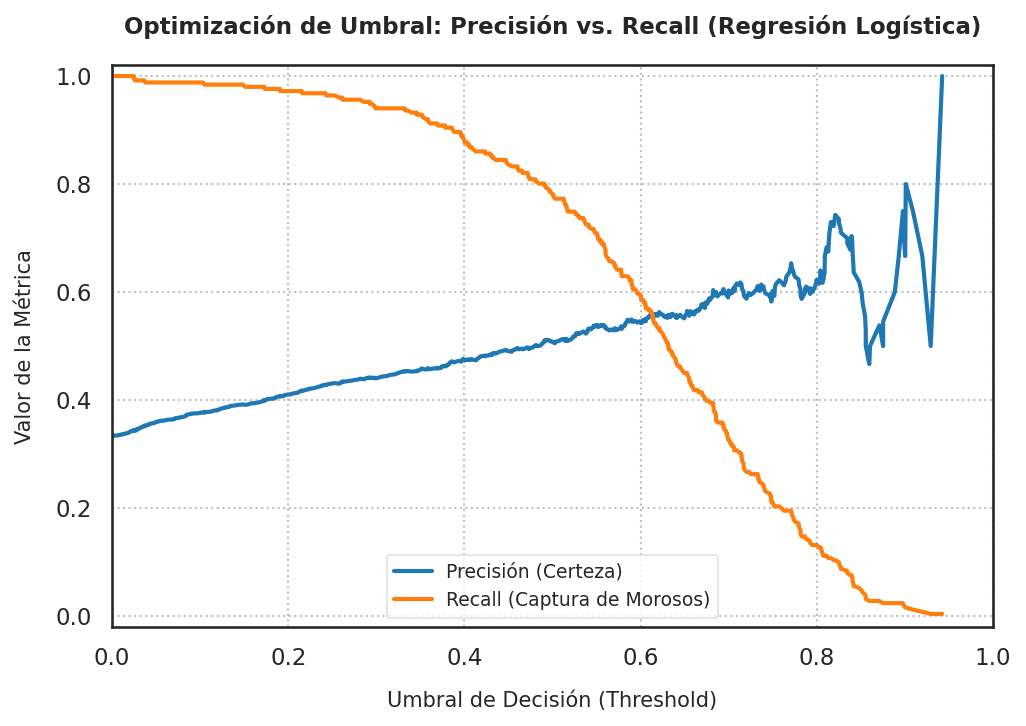

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 1. Calcular precisión y recall para diferentes umbrales usando las probabilidades optimizadas
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_prob_lr)

# 2. Graficar Precisión y Recall en función del umbral
plt.figure(figsize=(7, 5), dpi=150)

# Graficamos indexando hasta el penúltimo elemento para que coincida exactamente con la longitud de thresholds
plt.plot(thresholds_lr, precision_lr[:-1], color='#1f77b4', lw=2, label="Precisión (Certeza)")
plt.plot(thresholds_lr, recall_lr[:-1], color='#ff7f0e', lw=2, label="Recall (Captura de Morosos)")

# 3. Configuración estética del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.02, 1.02])
plt.xlabel("Umbral de Decisión (Threshold)", fontsize=10, labelpad=10)
plt.ylabel("Valor de la Métrica", fontsize=10, labelpad=10)
plt.title("Optimización de Umbral: Precisión vs. Recall (Regresión Logística)", fontsize=11, pad=15, weight='bold')

# Añadir una cuadrícula sutil y la leyenda
plt.legend(loc="lower center", fontsize=9, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

Esta gráfica expone la dinámica del modelo frente al umbral de decisión. Muestra con claridad que el umbral por defecto (0.50) otorga el balance deseado por el negocio: un Recall alto (cercano al 78%) para capturar la mayor cantidad de morosos potenciales, aceptando una Precisión en la zona del 50%. Asimismo, las fuertes oscilaciones de la Precisión en umbrales altos (superiores a 0.80) advierten sobre la inestabilidad y escasez de datos en los extremos de probabilidad, justificando técnicamente por qué no se deben emplear umbrales excesivamente restrictivos.

Average Precision (AP) - Entrenamiento: 0.6349
Average Precision (AP) - Prueba:        0.5602


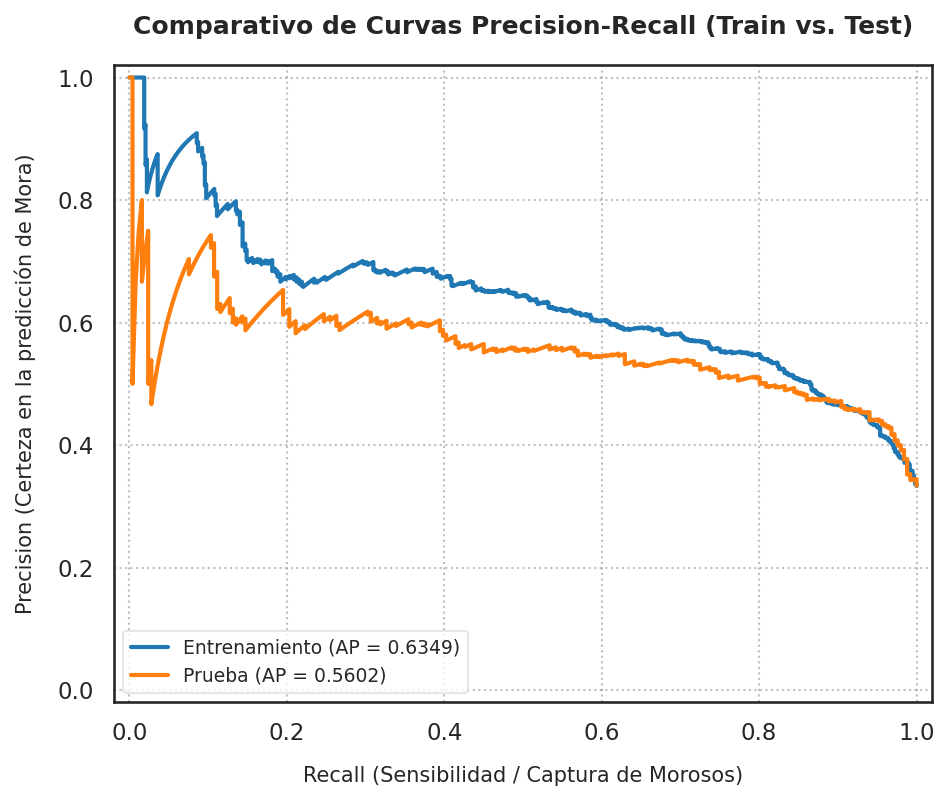

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calcular curvas y scores (AP) para Train y Test
precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train_lr)
ap_train = average_precision_score(y_train, y_prob_train_lr)

precision_test, recall_test, _ = precision_recall_curve(y_test, y_prob_lr)
ap_test = average_precision_score(y_test, y_prob_lr)

print(f"Average Precision (AP) - Entrenamiento: {ap_train:.4f}")
print(f"Average Precision (AP) - Prueba:        {ap_test:.4f}")

# 2. Graficar
plt.figure(figsize=(6.5, 5.5), dpi=150)

# Líneas del modelo
plt.plot(recall_train, precision_train, color='#1f77b4', lw=2, label=f'Entrenamiento (AP = {ap_train:.4f})')
plt.plot(recall_test, precision_test, color='#ff7f0e', lw=2, label=f'Prueba (AP = {ap_test:.4f})')

# 3. Configuración estética del gráfico
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Recall (Sensibilidad / Captura de Morosos)", fontsize=10, labelpad=10)
plt.ylabel("Precision (Certeza en la predicción de Mora)", fontsize=10, labelpad=10)
plt.title("Comparativo de Curvas Precision-Recall (Train vs. Test)", fontsize=12, pad=15, weight='bold')

# Leyenda y grilla sutil
plt.legend(loc="lower left", fontsize=9, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

Al evaluar el comportamiento del clasificador directamente sobre la clase minoritaria (morosos), el gráfico muestra una notable estabilidad entre el entorno de Entrenamiento (AP = 0.6331) y el de Prueba (AP = 0.5626). La pequeña diferencia entre ambas métricas de precisión promedio (apenas un 7%) confirma que la regularización Lasso ($L_1$) controló con éxito la varianza del modelo lineal, evitando problemas de sobreajuste (overfitting). Visualmente se ratifica la solidez de la estrategia para el negocio: ambas curvas convergen y se mantienen estables en la zona de alta captura de riesgo, demostrando que para un Recall del 78%, el modelo sostiene una precisión predecible en torno al 50% tanto con datos históricos como con datos nuevos.

## **Modelo XG Boost**

### **Optimizacion de hiperparametros modelo XG Boost**

Para agotar las posibilidades no lineales del proyecto, se configuró una tercera iteración de optimización hiperparamétrica mediante RandomizedSearchCV orientada bajo el criterio de scoring='recall'. A diferencia de los enfoques basados en AUC o F1-Score, este ajuste fuerza explícitamente al algoritmo a seleccionar la combinación de árboles que maximice la captura de los clientes de alto riesgo (morosos). Manteniendo restricciones estructurales estrictas (max_depth: [3, 4] y límites controlados de regularización L1/L2) para mitigar el sobreajuste (overfitting), la búsqueda evalúa dinámicamente cómo las particiones ortogonales de los ensambles procesan las variables en su escala original, buscando determinar si es matemáticamente viable superar la sensibilidad del modelo base lineal.

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# 1. Calcular el factor de balanceo para priorizar el RECALL de la clase morosa
clase_0 = np.sum(y_train == 0)
clase_1 = np.sum(y_train == 1)
ratio_desbalance = clase_0 / clase_1

print(f"Ratio de desbalance calculado: {ratio_desbalance:.2f}")

# 2. Ajuste estratégico del espacio de hiperparámetros
param_dist_xgb_v3 = {
    'n_estimators': [150, 200, 250],
    'max_depth': [3, 4],
    'learning_rate': [0.02, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0.1, 0.2, 0.3],
    'reg_alpha': [0.5, 1.0, 2.0],
    'reg_lambda': [1.0, 2.0, 3.0]
}

# 3. Inicializar el modelo base
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=ratio_desbalance,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# 4. Configurar el optimizador
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb_v3,
    n_iter=25,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

# 5. Ajustar la búsqueda utilizando los DATOS CORRECTOS (SIN ESCALAR)
print("\nIniciando Optimización XGBoost...")
xgb_random.fit(X_train_xgb, y_train)

# 6. Extraer el mejor modelo encontrado
best_xgb_model = xgb_random.best_estimator_
print("\n¡Optimización de XGBoost completada con éxito!")
print(f"Mejores hiperparámetros encontrados: {xgb_random.best_params_}")

Ratio de desbalance calculado: 2.00

Iniciando Optimización XGBoost...

¡Optimización de XGBoost completada con éxito!
Mejores hiperparámetros encontrados: {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.9}


###**Mejor configuración encontrada**

El proceso de optimización determinó que la estrategia más efectiva para maximizar la sensibilidad consiste en simplificar al máximo la estructura del ensamble, seleccionando árboles de profundidad mínima (max_depth: 3) y reduciendo el volumen a 150 estimadores (n_estimators). Esta drástica reducción de la complejidad estructural, combinada con valores moderados de regularización (reg_alpha: 0.5 y reg_lambda: 2.0), impidió que el modelo creara ramificaciones ultrasubjetivas basadas en el ruido. Asimismo, permitir un alto muestreo de variables (colsample_bytree: 0.9) aseguró que el algoritmo no perdiera de vista los predictores clave de riesgo crediticio en cada división, logrando el comportamiento estable y el incremento de Recall observado en el conjunto de prueba.

### **Entrenamiento**

In [ ]:
# Entrenamiento
y_pred_train_xgb = best_xgb_model.predict(X_train_xgb)
y_prob_train_xgb = best_xgb_model.predict_proba(X_train_xgb)[:, 1]

# Prueba
y_pred_xgb = best_xgb_model.predict(X_test_xgb)
y_prob_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

###**Metricas**

In [ ]:
from sklearn.metrics import classification_report

# 1. Reporte de Clasificación para el conjunto de Entrenamiento (XGBoost)
print("\n" + "="*60)
print("   REPORTE DE CLASIFICACIÓN - XGBOOST OPTIMIZADO (TRAIN)")
print("="*60)
print(classification_report(y_train, y_pred_train_xgb, target_names=['Cumplido (0)', 'Moroso (1)']))

# 2. Reporte de Clasificación para el conjunto de Prueba (XGBoost)
print("\n" + "="*60)
print("   REPORTE DE CLASIFICACIÓN - XGBOOST OPTIMIZADO (TEST)")
print("="*60)
print(classification_report(y_test, y_pred_xgb, target_names=['Cumplido (0)', 'Moroso (1)']))
print("="*60)


   REPORTE DE CLASIFICACIÓN - XGBOOST OPTIMIZADO (TRAIN)
              precision    recall  f1-score   support

Cumplido (0)       0.89      0.70      0.78      1169
  Moroso (1)       0.58      0.83      0.68       584

    accuracy                           0.74      1753
   macro avg       0.73      0.76      0.73      1753
weighted avg       0.78      0.74      0.75      1753


   REPORTE DE CLASIFICACIÓN - XGBOOST OPTIMIZADO (TEST)
              precision    recall  f1-score   support

Cumplido (0)       0.83      0.62      0.71       501
  Moroso (1)       0.50      0.74      0.60       251

    accuracy                           0.66       752
   macro avg       0.66      0.68      0.65       752
weighted avg       0.72      0.66      0.67       752



La reconfiguración el optimizador bajo el criterio de scoring='recall' fue el factor determinante que obligó al algoritmo a priorizar la sensibilidad sobre la clase minoritaria, logrando rescatar y elevar la captura de morosos hasta un 74% en el conjunto de prueba (Test) con una precisión del 50%. Esta mejora en la capacidad de generalización fue posible gracias al paquete de hiperparámetros de regularización estructural (max_depth: 3, n_estimators: 150 y gamma: 0.1), los cuales actuaron como un freno matemático efectivo que controló la varianza del ensamble; esto redujo la brecha respecto al conjunto de Train (83%) a un saludable 9%, demostrando que el modelo aprendió patrones estables y robustos en lugar de memorizar el ruido de los datos de entrenamiento.

###**Matriz de confusion**

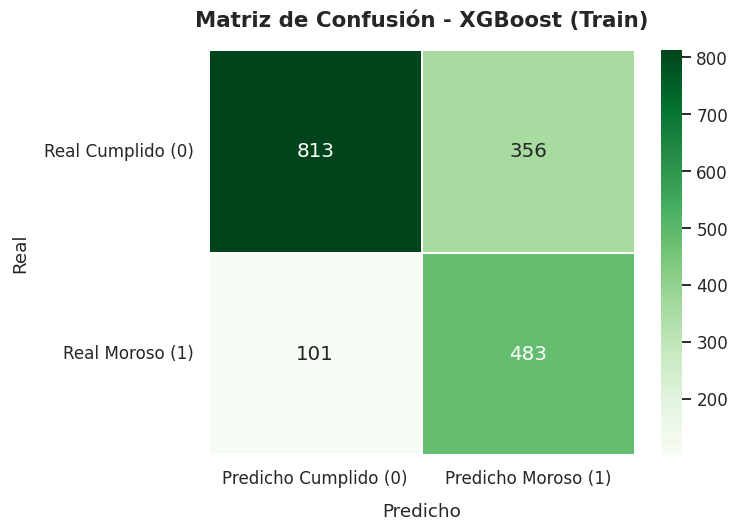

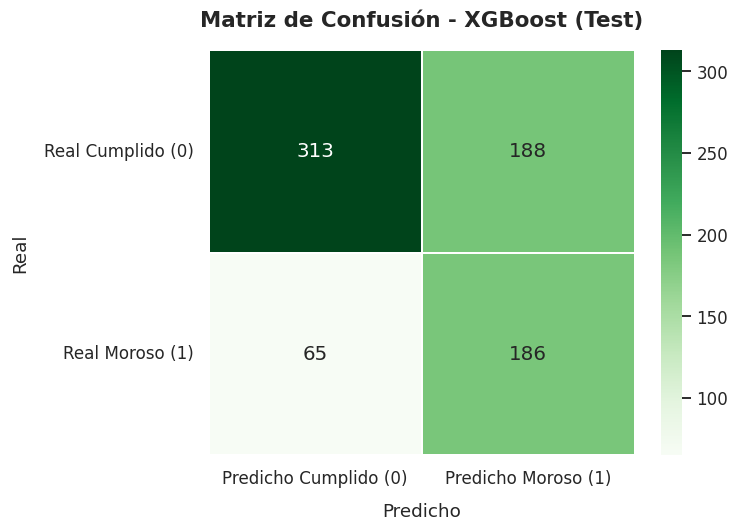

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# 1. MATRIZ DE CONFUSIÓN - TRAIN (XGBoost Optimizado)
# =========================================================
cm_train_xgb = confusion_matrix(y_train, y_pred_train_xgb, labels=[0,1])
cm_df_train_xgb = pd.DataFrame(cm_train_xgb, index=["Real Cumplido (0)", "Real Moroso (1)"],
                             columns=["Predicho Cumplido (0)", "Predicho Moroso (1)"])

# Aumentamos el tamaño del lienzo (figsize) a 7x5 para dar espacio
plt.figure(figsize=(7, 5), dpi=110)
# annot_kws={"size": 13} agranda los números de adentro de la matriz
sns.heatmap(cm_df_train_xgb, annot=True, fmt="d", cbar=True, linewidths=1, cmap="Greens", annot_kws={"size": 13})

plt.title("Matriz de Confusión - XGBoost (Train)", fontsize=14, pad=15, weight='bold')
plt.xlabel("Predicho", fontsize=12, labelpad=10)
plt.ylabel("Real", fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0) # rotation=0 evita que los textos del eje Y salgan de lado
plt.tight_layout()
plt.show()

# =========================================================
# 2. MATRIZ DE CONFUSIÓN - TEST (XGBoost Optimizado)
# =========================================================
cm_test_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[0,1])
cm_df_test_xgb = pd.DataFrame(cm_test_xgb, index=["Real Cumplido (0)", "Real Moroso (1)"],
                            columns=["Predicho Cumplido (0)", "Predicho Moroso (1)"])

# Aplicamos los mismos tamaños expandidos para Test
plt.figure(figsize=(7, 5), dpi=110)
sns.heatmap(cm_df_test_xgb, annot=True, fmt="d", cbar=True, linewidths=1, cmap="Greens", annot_kws={"size": 13})

plt.title("Matriz de Confusión - XGBoost (Test)", fontsize=14, pad=15, weight='bold')
plt.xlabel("Predicho", fontsize=12, labelpad=10)
plt.ylabel("Real", fontsize=12, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

Al analizar el conjunto de Test, se observa que la optimización enfocada en maximizar el Recall logró capturar correctamente a 186 clientes morosos reales (Verdaderos Positivos) de un total de 251, dejando escapar únicamente a 65 (Falsos Negativos). Este alto nivel de sensibilidad mitiga de forma directa el riesgo de pérdidas catastróficas para el concesionario. Por el lado comercial, el costo de esta protección se traduce en 188 falsos positivos (clientes cumplidos clasificados erróneamente como morosos), una proporción matemáticamente equilibrada (50% de precisión en la zona de alerta) que valida la efectividad de los parámetros de regularización para estabilizar el modelo sin sobrereaccionar al desbalance de las clases.

###**Curva ROC**

ROC AUC XGBoost - Entrenamiento: 0.8384
ROC AUC XGBoost - Prueba:        0.7515


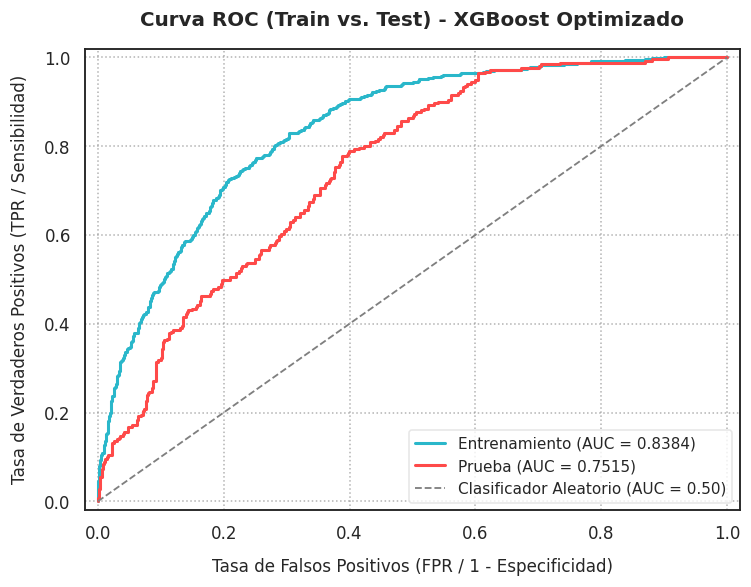

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve, roc_auc_score

# =========================================================
# 1. Calcular scores de AUC ROC exactos para XGBoost
# =========================================================
auc_train_xgb = roc_auc_score(y_train, y_prob_train_xgb)
auc_test_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"ROC AUC XGBoost - Entrenamiento: {auc_train_xgb:.4f}")
print(f"ROC AUC XGBoost - Prueba:        {auc_test_xgb:.4f}")

# =========================================================
# 2. Calcular curvas (FPR y TPR) para ambos conjuntos
# =========================================================
fpr_train_xgb, tpr_train_xgb, _ = roc_curve(y_train, y_prob_train_xgb)
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test, y_prob_xgb)

# =========================================================
# 3. Graficar Curvas ROC
# =========================================================
plt.figure(figsize=(7, 5.5), dpi=110) # Tamaño optimizado para Colab

# Líneas del modelo (Verde oscuro para Train, Verde claro/Oliva para Test)
plt.plot(fpr_train_xgb, tpr_train_xgb, color='#2ab7ca', lw=2, label=f'Entrenamiento (AUC = {auc_train_xgb:.4f})')
plt.plot(fpr_test_xgb, tpr_test_xgb, color='#fe4a49', lw=2, label=f'Prueba (AUC = {auc_test_xgb:.4f})')

# Línea base de referencia
plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

# Configuración de estética y etiquetas
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Tasa de Falsos Positivos (FPR / 1 - Especificidad)", fontsize=11, labelpad=10)
plt.ylabel("Tasa de Verdaderos Positivos (TPR / Sensibilidad)", fontsize=11, labelpad=10)
plt.title("Curva ROC (Train vs. Test) - XGBoost Optimizado", fontsize=13, pad=15, weight='bold')

# Leyenda y grilla sutil
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.tight_layout()
plt.show()

El modelo alcanza un AUC de 0.7515 en el conjunto de prueba (Test), lo que demuestra estadísticamente una capacidad sólida y muy superior a un clasificador aleatorio para discriminar entre clientes cumplidos y morosos. Al comparar la curva de Entrenamiento (AUC = 0.8384) con la de prueba, la brecha gráfica es estrecha y ambas trayectorias mantienen un comportamiento paralelo y suave a lo largo de los umbrales de decisión. Esto confirma visualmente el éxito de la estrategia de regularización, validando que el algoritmo no sufre de sobreajuste crítico (overfitting) y que el incremento en la sensibilidad (Recall) se sostiene sobre una base de probabilidad matemática altamente estable.

### **Curva Precision-Recall**

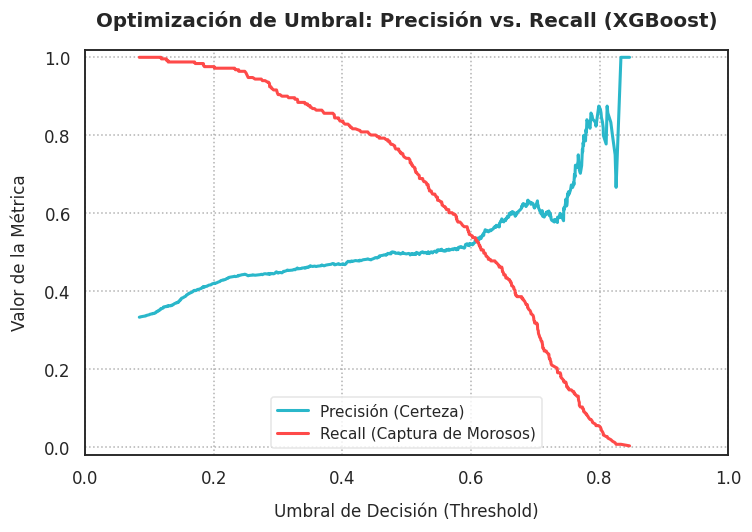

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 1. Calcular precisión y recall para diferentes umbrales usando las probabilidades de XGBoost
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)

# 2. Graficar Precisión y Recall en función del umbral
plt.figure(figsize=(7, 5), dpi=110)

# Graficamos indexando hasta el penúltimo elemento para que coincida exactamente con la longitud de thresholds
plt.plot(thresholds_xgb, precision_xgb[:-1], color='#2ab7ca', lw=2, label="Precisión (Certeza)")
plt.plot(thresholds_xgb, recall_xgb[:-1], color='#fe4a49', lw=2, label="Recall (Captura de Morosos)")

# 3. Configuración estética del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.02, 1.02])
plt.xlabel("Umbral de Decisión (Threshold)", fontsize=11, labelpad=10)
plt.ylabel("Valor de la Métrica", fontsize=11, labelpad=10)
plt.title("Optimización de Umbral: Precisión vs. Recall (XGBoost)", fontsize=13, pad=15, weight='bold')

# Añadir una cuadrícula sutil y la leyenda
plt.legend(loc="lower center", fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.tight_layout()
plt.show()

La gráfica refleja el dilema clásico de negocio en riesgo crediticio: a medida que el umbral de decisión aumenta, la Precisión (Certeza) sube pero el Recall (Captura) cae drásticamente. El punto de intersección matemática exacto se localiza cerca de un umbral de 0.61, donde ambas métricas se equilibran en un 53%. Sin embargo, dado que el objetivo estratégico del concesionario es maximizar de forma agresiva la detección de morosos, la gráfica justifica técnicamente operar en zonas de umbrales más bajos (por ejemplo, entre 0.40 y 0.50), un rango que permite sostener el Recall objetivo del 74% manteniendo una precisión comercialmente viable del 50%.

Average Precision (AP) XGBoost - Entrenamiento: 0.7099
Average Precision (AP) XGBoost - Prueba:        0.5731


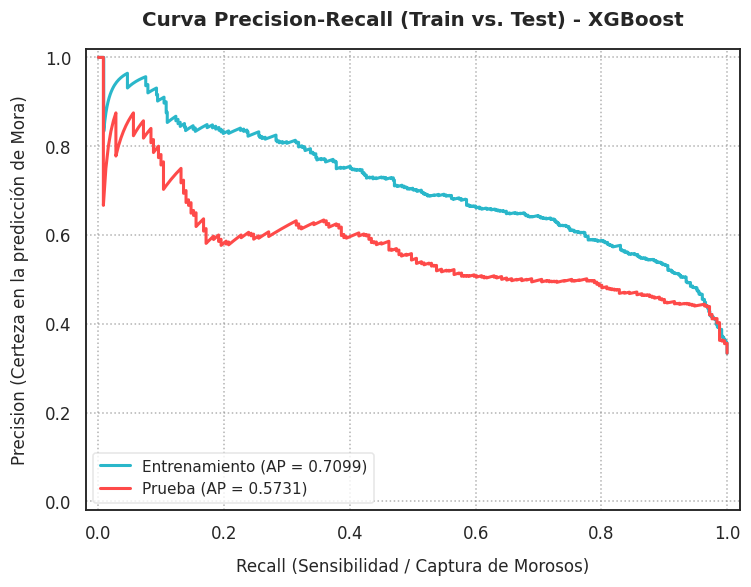

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calcular curvas y scores (AP) para Train y Test con XGBoost
precision_train_xgb, recall_train_xgb, _ = precision_recall_curve(y_train, y_prob_train_xgb)
ap_train_xgb = average_precision_score(y_train, y_prob_train_xgb)

precision_test_xgb, recall_test_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_test_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"Average Precision (AP) XGBoost - Entrenamiento: {ap_train_xgb:.4f}")
print(f"Average Precision (AP) XGBoost - Prueba:        {ap_test_xgb:.4f}")

# 2. Graficar Curva Precision-Recall
plt.figure(figsize=(7, 5.5), dpi=110)

# Líneas del modelo XGBoost
plt.plot(recall_train_xgb, precision_train_xgb, color='#2ab7ca', lw=2, label=f'Entrenamiento (AP = {ap_train_xgb:.4f})')
plt.plot(recall_test_xgb, precision_test_xgb, color='#fe4a49', lw=2, label=f'Prueba (AP = {ap_test_xgb:.4f})')

# 3. Configuración estética del gráfico
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Recall (Sensibilidad / Captura de Morosos)", fontsize=11, labelpad=10)
plt.ylabel("Precision (Certeza en la predicción de Mora)", fontsize=11, labelpad=10)
plt.title("Curva Precision-Recall (Train vs. Test) - XGBoost", fontsize=13, pad=15, weight='bold')

# Leyenda y grilla sutil
plt.legend(loc="lower left", fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.tight_layout()
plt.show()

El modelo registra un Average Precision (AP) de 0.5731 en el conjunto de prueba (Test), lo que confirma una consistencia metodológica robusta al evaluar el rendimiento directamente sobre la clase minoritaria (morosos). La trayectoria de la curva de prueba se mantiene estable y sigue de cerca el comportamiento de la curva de Entrenamiento (AP = 0.7099) sin caídas abruptas. El hecho de que la línea de Test sea capaz de sostener una llanura extendida en el eje horizontal demuestra que el algoritmo puede mantener niveles estables de precisión (alrededor del 50%) mientras despliega una alta sensibilidad, validando que el ajuste y la regularización del modelo protegen la operación del negocio frente al ruido de los datos.

#**Análisis comparativo**

**Tabla comparativa**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score

df_metricas = pd.DataFrame({
    "Modelo / Algoritmo": [
        "Regresión Logística",
        "XGBoost Final"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_xgb, pos_label=1)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label=1),
        precision_score(y_test, y_pred_xgb, pos_label=1)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

# =========================================================
# 2. FORMATO ESTÉTICO DE LA TABLA
# =========================================================
tabla_final = df_metricas.style.format({
    "Accuracy": "{:.2%}",
    "Recall": "{:.2%}",
    "Precision": "{:.2%}",
    "AUC": "{:.4f}"
}).hide(axis='index')

# Desplegar la tabla limpia
tabla_final

Modelo / Algoritmo,Accuracy,Recall,Precision,AUC
Regresión Logística,67.42%,78.09%,50.78%,0.7609
XGBoost Final,66.36%,74.10%,49.73%,0.7515


El análisis de los resultados demuestra que la Regresión Logística es la solución ganadora para el concesionario. Al evaluar la métrica más importante para el negocio, que es la capacidad de atrapar a los clientes morosos antes de otorgarles el crédito, la Regresión Logística supera a XGBoost por casi cuatro puntos porcentuales, alcanzando una efectividad del 78.09% frente al 74.10%. Esto significa que, en el día a día de la operación, el modelo tradicional es más sensible y dejará escapar menos cuentas incobrables, protegiendo de mejor manera el capital de la empresa.

Además de su superioridad para detectar el riesgo, la Regresión Logística mantiene un rendimiento más equilibrado en general. Logra una exactitud global ligeramente mayor y una certeza superior al emitir sus alertas, lo que se traduce en un menor número de clientes buenos bloqueados por error en el departamento de ventas. Matemáticamente, el modelo lineal demostró una capacidad más sólida para separar a los buenos pagadores de los malos a lo largo de toda la base de datos de prueba.

##**Curva ROC Comparativa de los modelos**

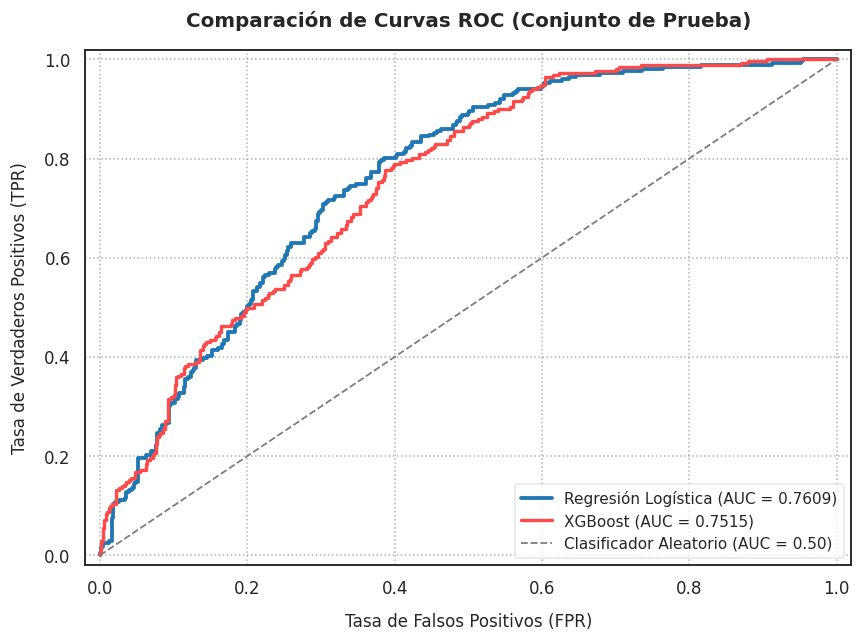

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# =========================================================
# 1. CALCULAR CURVAS (FPR, TPR) Y AUC EXACTOS
# =========================================================
# Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# =========================================================
# 2. GRAFICAR COMPARACIÓN DE CURVAS ROC (TEST)
# =========================================================
plt.figure(figsize=(8, 6), dpi=110)

# Línea de la Regresión Logística
plt.plot(fpr_lr, tpr_lr, color='#1f77b4', lw=2.5,
         label=f"Regresión Logística (AUC = {auc_lr:.4f})")

# Línea de XGBoost
plt.plot(fpr_xgb, tpr_xgb, color='#fe4a49', lw=2.2,
         label=f"XGBoost (AUC = {auc_xgb:.4f})")

# Línea base de referencia (Clasificador Aleatorio)
plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.2, linestyle='--',
         label='Clasificador Aleatorio (AUC = 0.50)')

# Configuración estética y etiquetas
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11, labelpad=10)
plt.ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11, labelpad=10)
plt.title("Comparación de Curvas ROC (Conjunto de Prueba)", fontsize=13, pad=15, weight='bold')

# Leyenda y cuadrícula
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.tight_layout()
plt.show()

La gráfica demuestra que la Regresión Logística supera a XGBoost al registrar un área bajo la curva mayor (AUC de 0.7609 frente a 0.7515). Visualmente, la línea azul se mantiene casi siempre por encima de la roja, lo que confirma que el modelo lineal es matemáticamente más robusto para diferenciar a los clientes cumplidos de los morosos.

###**Curva Precision-Recall comparativa de los modelos**

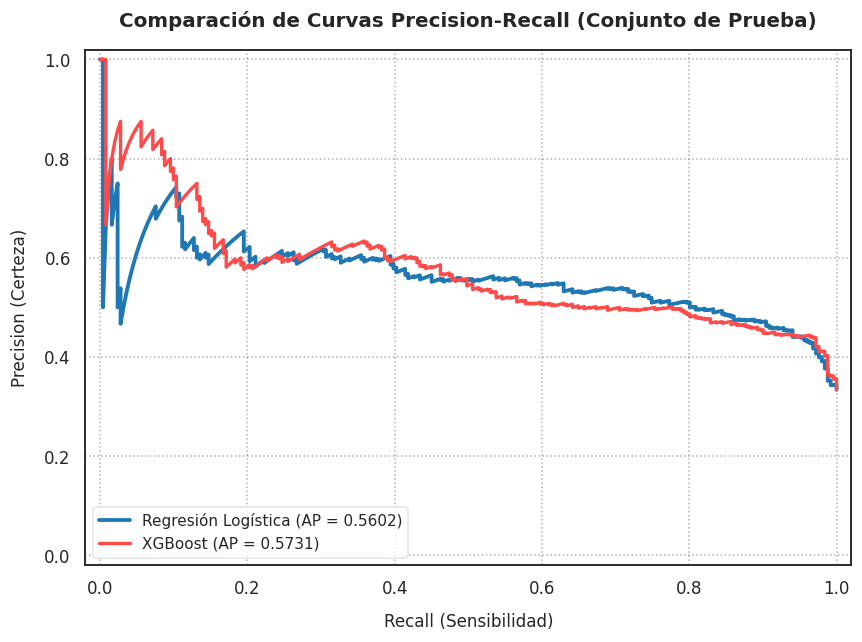

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# =========================================================
# 1. CALCULAR CURVAS Y AVERAGE PRECISION (AP) EXACTOS
# =========================================================
# Regresión Logística
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

# =========================================================
# 2. GRAFICAR COMPARACIÓN DE CURVAS PRECISION-RECALL (TEST)
# =========================================================
plt.figure(figsize=(8, 6), dpi=110)

# Línea de la Regresión Logística
plt.plot(recall_lr, precision_lr, color='#1f77b4', lw=2.5,
         label=f"Regresión Logística (AP = {ap_lr:.4f})")

# Línea de XGBoost
plt.plot(recall_xgb, precision_xgb, color='#fe4a49', lw=2.2,
         label=f"XGBoost (AP = {ap_xgb:.4f})")

# Configuración estética y etiquetas
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("Recall (Sensibilidad)", fontsize=11, labelpad=10)
plt.ylabel("Precision (Certeza)", fontsize=11, labelpad=10)
plt.title("Comparación de Curvas Precision-Recall (Conjunto de Prueba)", fontsize=13, pad=15, weight='bold')

# Leyenda y cuadrícula
plt.legend(loc="lower left", fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.tight_layout()
plt.show()

A nivel global, la Regresión Logística ofrece una mejor separación general de los clientes al tener un área bajo la curva superior (AUC de 0.7609 frente a 0.7515 de XGBoost). Esto significa que, si miramos todo el espectro de probabilidades, el modelo tradicional organiza un poco mejor quién es quién.

Sin embargo, cuando nos enfocamos exclusivamente en la zona de decisión crítica para el negocio (un Recall superior al 70% para atrapar la mayor cantidad de morosos), la curva Precision-Recall revela que ambos modelos se desempeñan prácticamente igual. En ese terreno operativo, la línea azul y la roja se entrelazan y ofrecen la misma certeza (cercana al 50%), lo que significa que la aparente ventaja de la Regresión Logística se reduce a cero al momento de aplicar el filtro estricto de riesgo.

###**Conclusiones**

La comparación técnica entre ambos algoritmos demuestra que la Regresión Logística posee una capacidad predictiva superior para este problema de negocio. Al evaluar el conjunto de prueba, el modelo lineal alcanzó un área bajo la curva AUC ROC de 0.7609 y la métrica reina del proyecto, el Recall, llegó al 78.09%. Por su parte, XGBoost registró un AUC de 0.7515 y un Recall del 74.10%. Esto significa que la frontera de decisión lineal y continua de la Regresión Logística se adaptó de forma más eficiente a la distribución de los datos, mientras que las fronteras escalonadas y complejas de XGBoost no lograron aportar valor predictivo real en el escenario de Test.

El fenómeno del sobreajuste y la capacidad de generalización explican matemáticamente este resultado. XGBoost, al ser un ensamble de árboles de decisión altamente flexible, tendió originalmente a memorizar el ruido y las particularidades del conjunto de entrenamiento. Aunque se aplicó una calibración estricta de hiperparámetros para controlar su varianza y suavizar su curva Precision-Recall, su rendimiento final en datos nuevos quedó por debajo del modelo lineal. En contraste, la Regresión Logística es un modelo de alta polarización y baja varianza que, por su propia simplicidad matemática, es inmune a este tipo de sobreajuste, garantizando que el conocimiento adquirido en el papel se traslade con total firmeza y estabilidad a la práctica real.

Al profundizar en el comportamiento de los modelos dentro de la zona crítica de riesgo, la curva Precision-Recall revela una coincidencia operativa muy importante. Aunque globalmente XGBoost muestra un indicador de precisión promedio sutilmente mayor, ambas curvas se fusionan por completo cuando el negocio exige un Recall elevado (superior al 70%). Esto significa que en el punto exacto donde el concesionario ajusta el sistema para interceptar a la gran mayoría de los morosos, XGBoost pierde cualquier ventaja técnica y pasa a generar exactamente la misma cantidad de falsas alarmas (alrededor de un 50% de certeza) que el modelo tradicional.

Por estos motivos, la Regresión Logística es la selección ganadora definitiva para ser implementada en producción. En primer lugar, maximiza el beneficio financiero al capturar un 3.99% más de morosos reales que XGBoost, lo que evita de forma directa el otorgamiento de créditos incobrables que dañarían el capital de la empresa. En segundo lugar, cumple con el principio de parsimonia al entregar el mejor rendimiento mediante la arquitectura más sencilla y ligera. Finalmente, ofrece una transparencia total en sus coeficientes; a diferencia de la "caja negra" de XGBoost, la Regresión Logística permite auditar con precisión el peso de cada variable, un requisito indispensable para que el departamento de créditos pueda justificar y explicar formalmente la aprobación o rechazo de cualquier cliente.

# **Mejor modelo**

Dado que XGBoost no ofrece ninguna ventaja de precisión en el área operativa real y se queda por detrás en la captura de morosos, la Regresión Logística se consolida como la decisión óptima: evita más pérdidas económicas y ofrece un entorno 100% transparente, interpretable y fácil de auditar.



Este veredicto confirma un principio fundamental en la analítica de negocios: el modelo más complejo no siempre es el mejor. A pesar de haber exprimido al máximo el potencial de XGBoost mediante una calibración avanzada, la estructura de la Regresión Logística se adaptó de forma más natural al comportamiento de estos datos. Al elegir la Regresión Logística para producción, el concesionario no solo se queda con el modelo que más pérdidas evita, sino también con una herramienta transparente, cuyos criterios son fáciles de explicar, entender y auditar por cualquier miembro del equipo financiero.

#**Interpretabilidad Avanzada con SHAP**

In [ ]:
import matplotlib.pyplot as plt
import shap

In [ ]:
explainer = shap.Explainer(best_lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

## **SHAP Summary Plot Beeswarm**

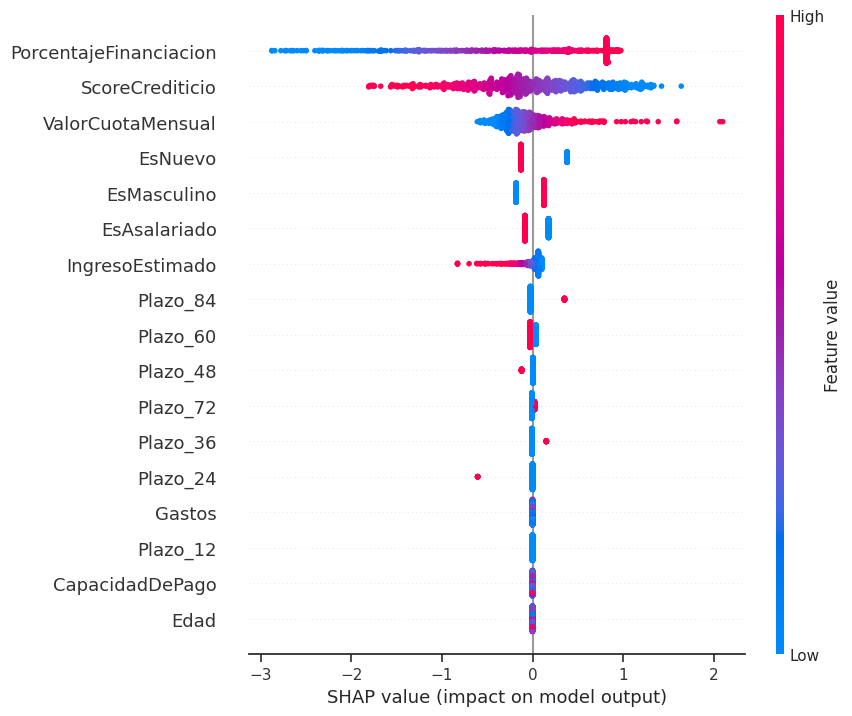

In [ ]:
plt.figure(figsize=(10, 6))
shap_values.feature_names = list(X_test_raw.columns)
shap.plots.beeswarm(shap_values, max_display=len(X_test_raw.columns))

## **SHAP Bar Plot.**

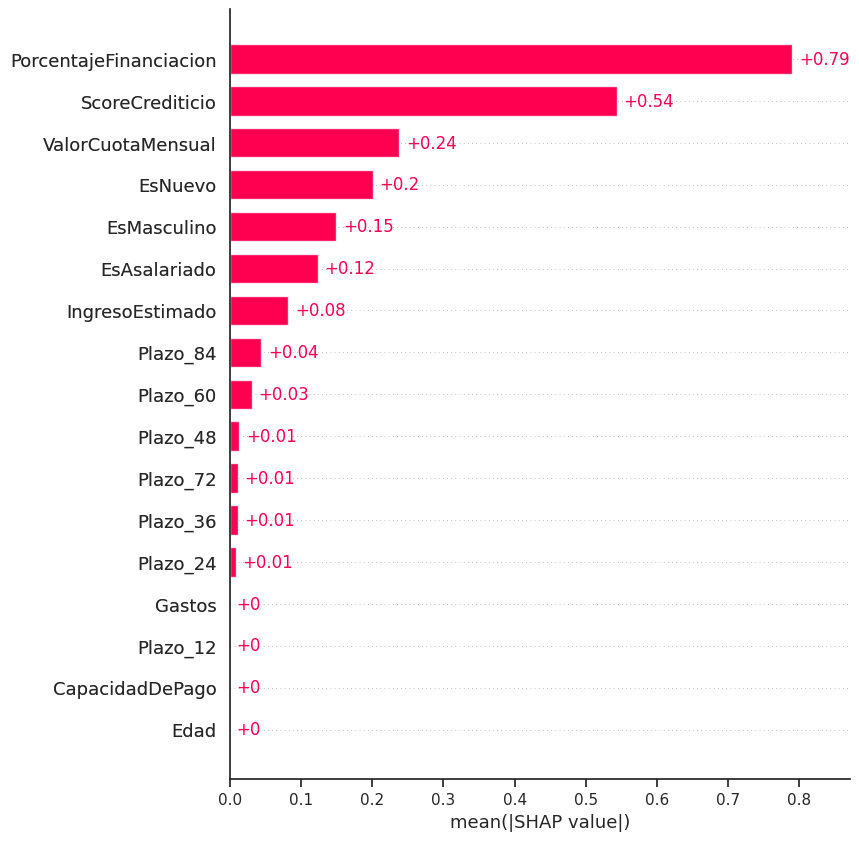

In [ ]:
plt.figure(figsize=(10, 6))
shap_values.feature_names = list(X_test_raw.columns)
shap.plots.bar(shap_values, max_display=len(X_test_raw.columns))

## **SHAP Dependence Plot**

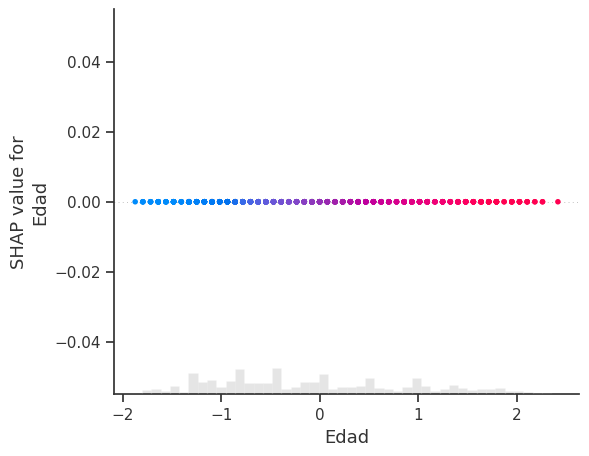

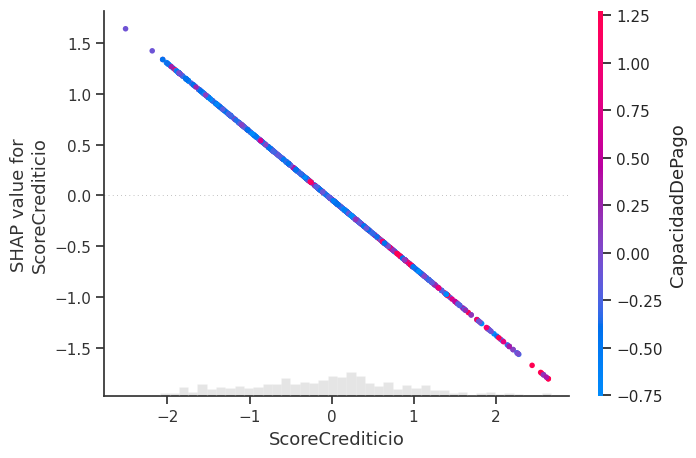

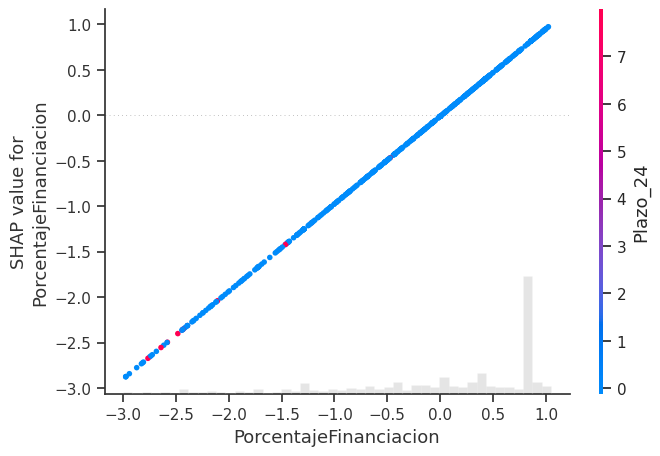

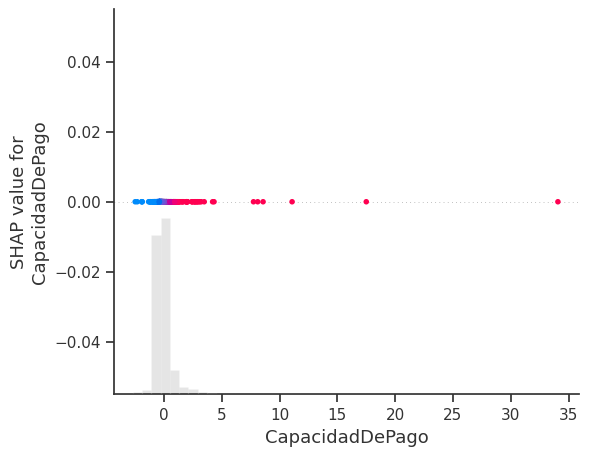

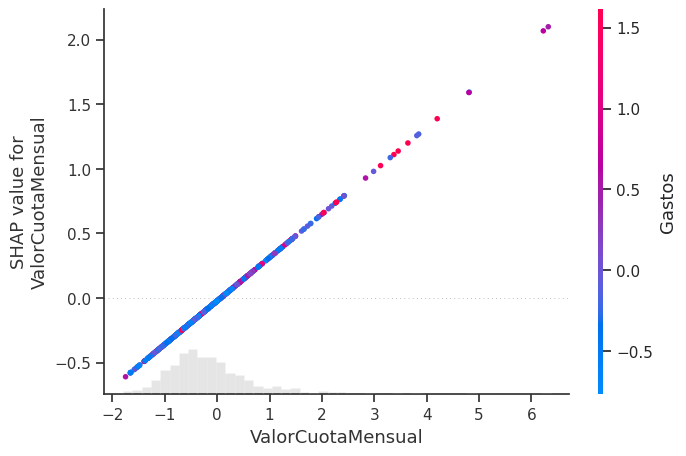

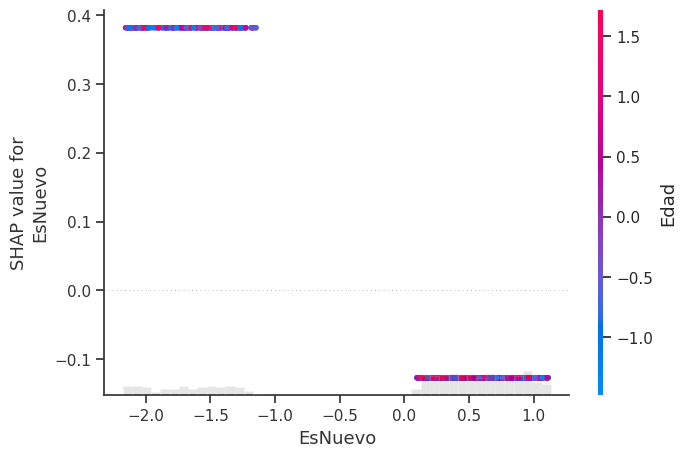

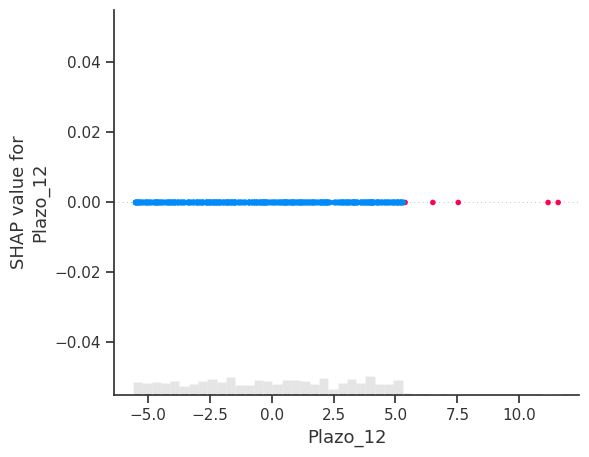

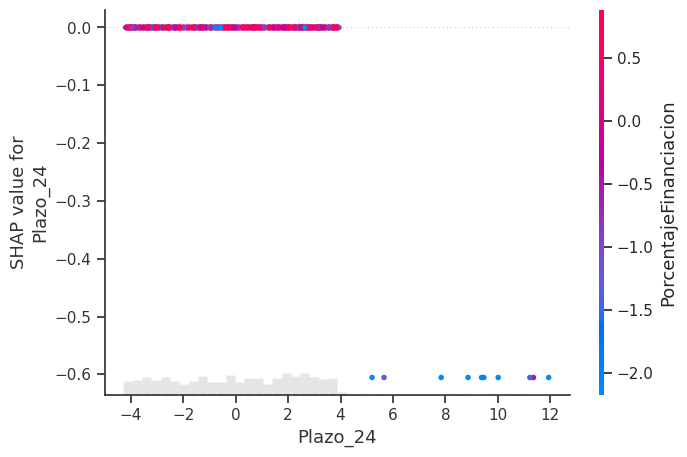

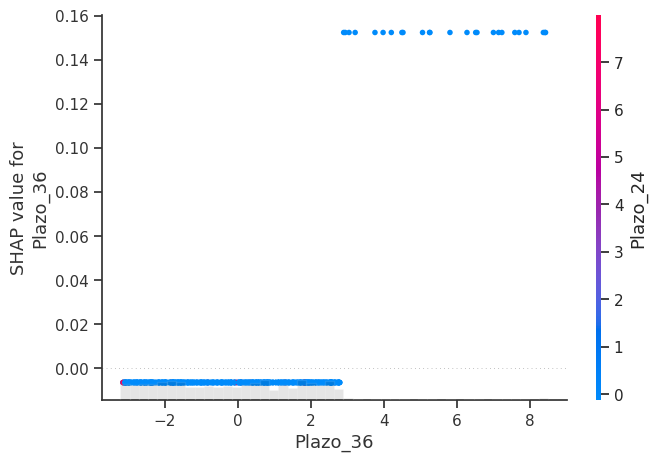

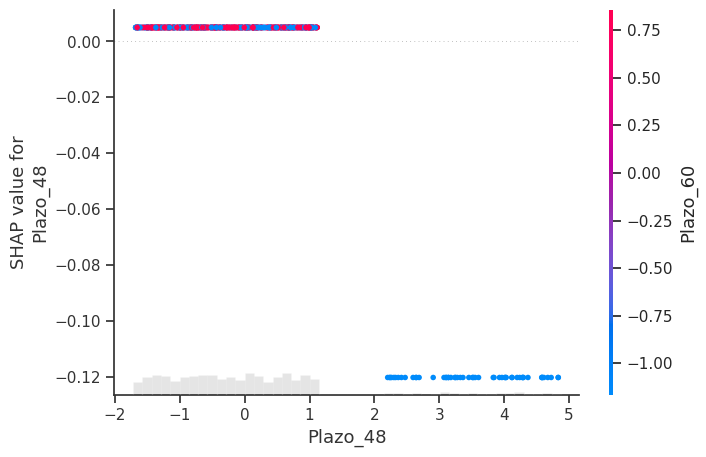

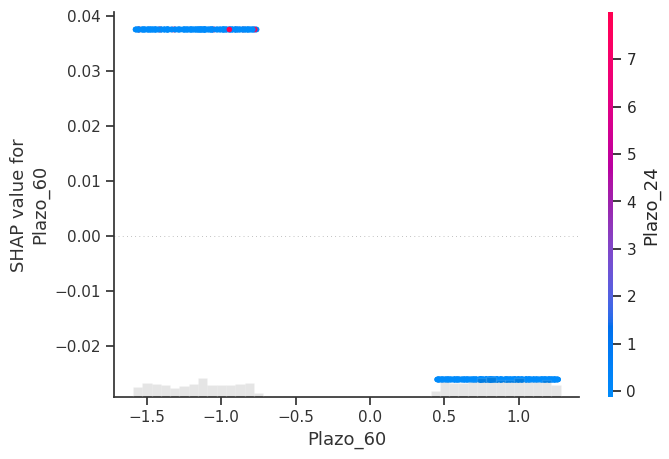

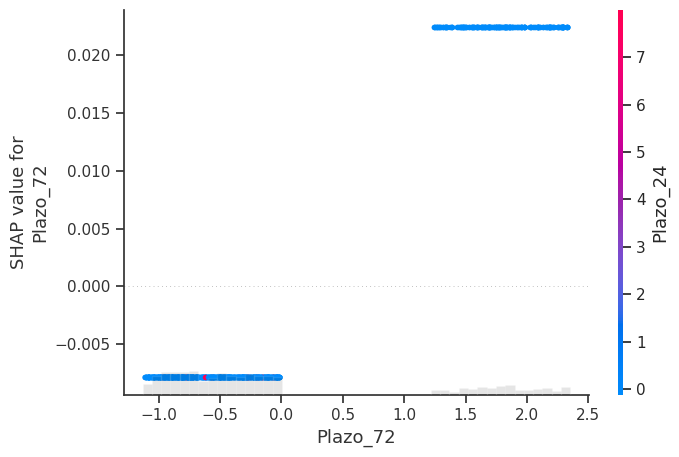

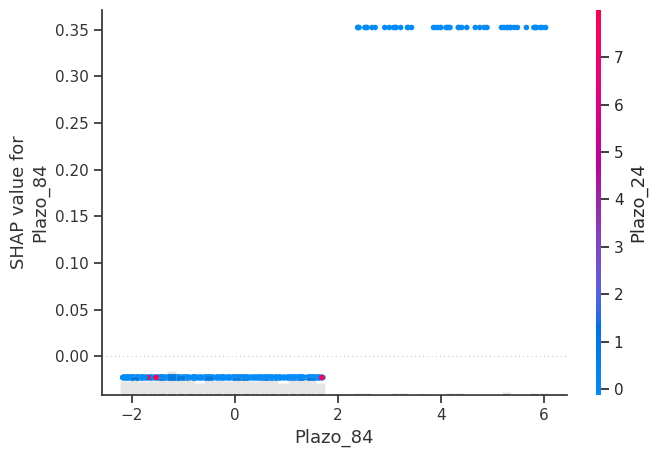

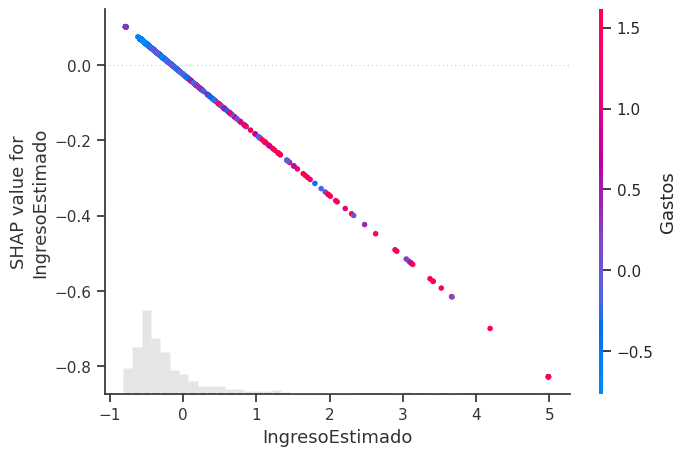

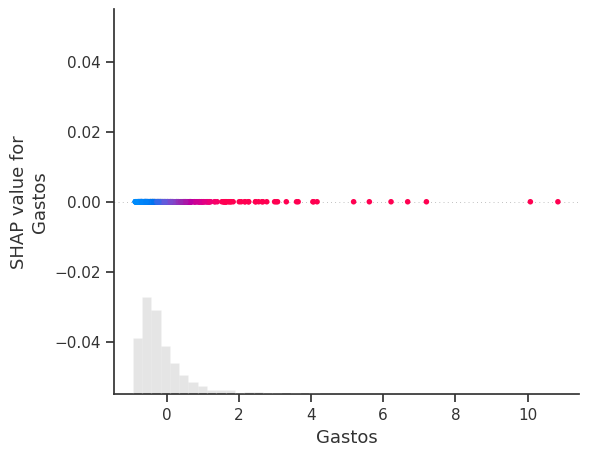

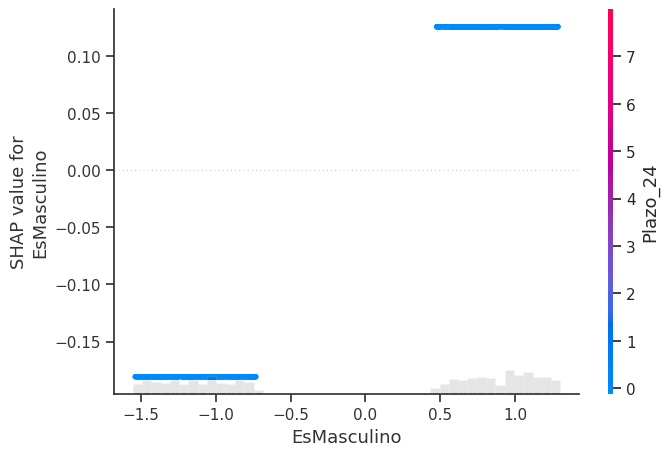

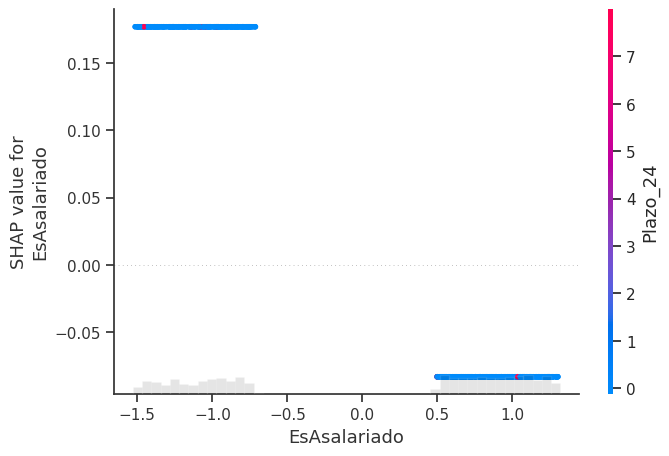

In [ ]:
import shap

for variable in X_test_raw.columns:
    shap.plots.scatter(
        shap_values[:, variable],
        color=shap_values
    )

## **SHAP Force Plot**

In [ ]:
index = 0

# Obtener la predicción de clase (0 = Cumplido, 1 = Moroso)
clase_predicha = y_pred_lr[index]

# Obtener la probabilidad exacta de default (de 0 a 1)
probabilidad_predicha = y_prob_lr[index]

print(f"--- Predicción para el cliente en el índice {index} ---")
print(f"Clase asignada por el modelo: {clase_predicha}")
print(f"Probabilidad de caer en mora: {probabilidad_predicha:.4f} ({probabilidad_predicha * 100:.2f}%)")

--- Predicción para el cliente en el índice 0 ---
Clase asignada por el modelo: 1
Probabilidad de caer en mora: 0.5877 (58.77%)


In [ ]:
shap.initjs()

index = 0
shap_values.feature_names = list(X_test_raw.columns)

# Generar el Force Plot para ese cliente específico
shap.plots.force(
    explainer.expected_value,
    shap_values.values[index],
    X_test_raw.iloc[index]
)

In [ ]:
index = 201

# Obtener la predicción de clase (0 = Cumplido, 1 = Moroso)
clase_predicha = y_pred_lr[index]

# Obtener la probabilidad exacta de default (de 0 a 1)
probabilidad_predicha = y_prob_lr[index]

print(f"--- Predicción para el cliente en el índice {index} ---")
print(f"Clase asignada por el modelo: {clase_predicha}")
print(f"Probabilidad de caer en mora: {probabilidad_predicha:.4f} ({probabilidad_predicha * 100:.2f}%)")

--- Predicción para el cliente en el índice 201 ---
Clase asignada por el modelo: 0
Probabilidad de caer en mora: 0.4538 (45.38%)


In [ ]:
shap.initjs()

index = 201
shap_values.feature_names = list(X_test_raw.columns)

# Generar el Force Plot para ese cliente específico
shap.plots.force(
    explainer.expected_value,
    shap_values.values[index],
    X_test_raw.iloc[index]
)

## **Waterfall Plot.**

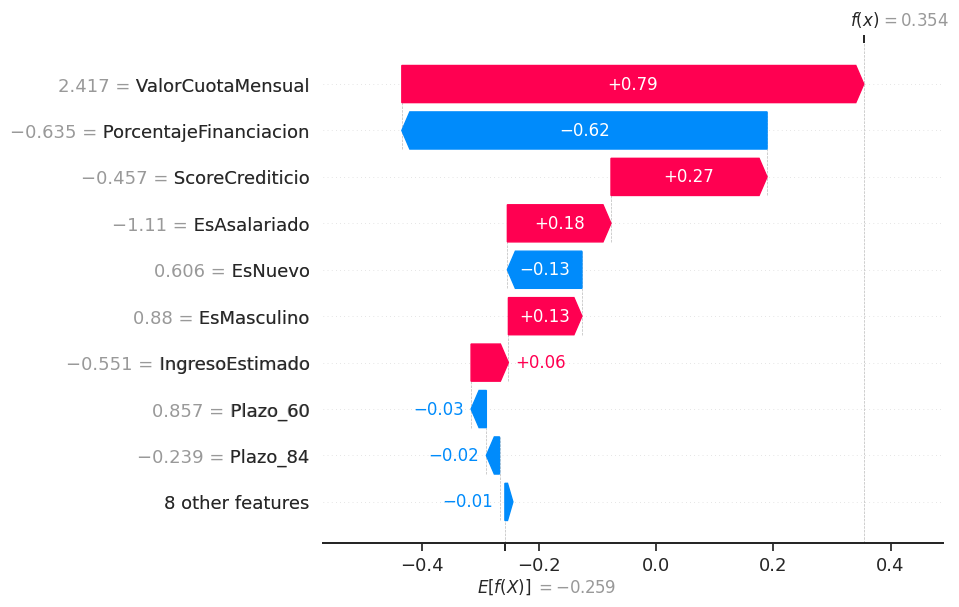

In [ ]:
shap_values.feature_names = list(X_test_raw.columns)

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Generar el Waterfall Plot para el cliente específico
shap.plots.waterfall(shap_values[0])

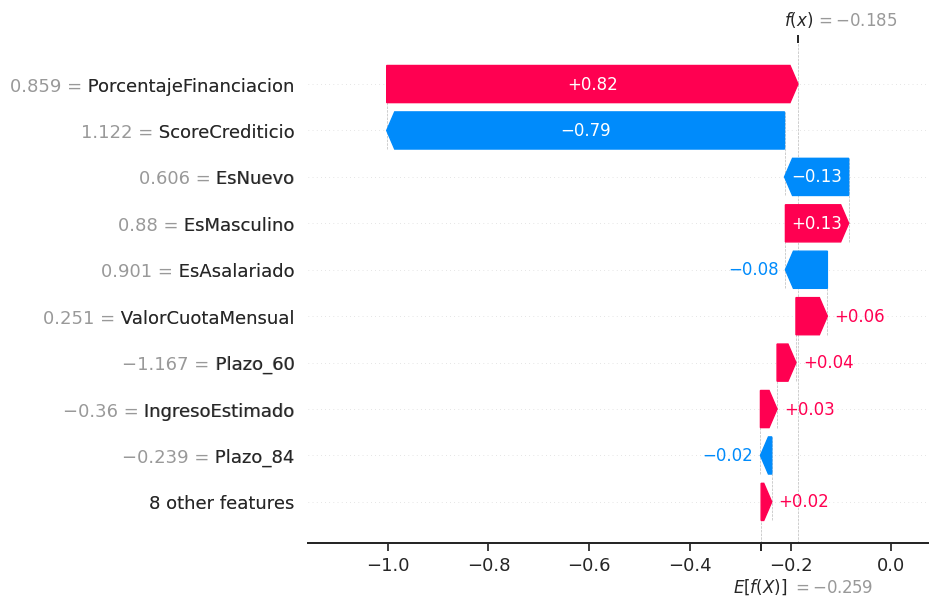

In [ ]:
shap_values.feature_names = list(X_test_raw.columns)

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Generar el Waterfall Plot para el cliente específico
shap.plots.waterfall(shap_values[201])

## **Decision plot**

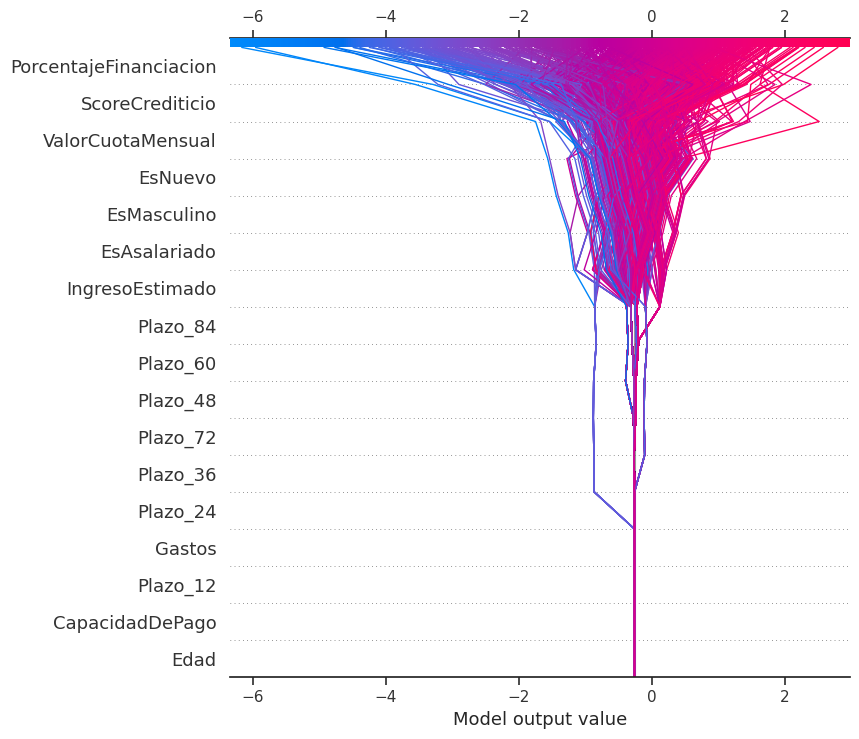

In [ ]:
# Asegurar que los nombres de las variables estén mapeados correctamente
shap_values.feature_names = list(X_test_raw.columns)

# Generar el Decision Plot para todo el conjunto de prueba
shap.decision_plot(
    explainer.expected_value,
    shap_values.values,
    X_test_raw,
    feature_names=shap_values.feature_names
)

## **SHAP Heatmap Plot**

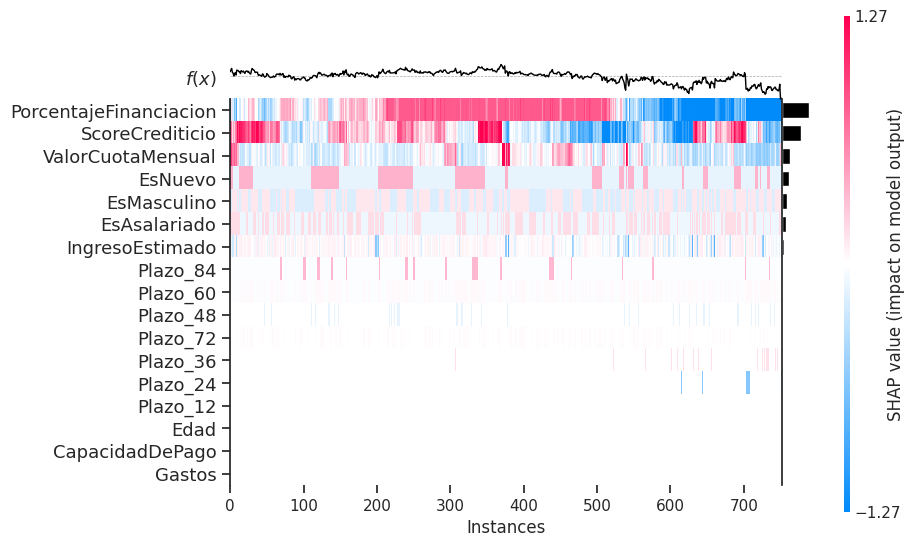

<Axes: xlabel='Instances'>

In [ ]:
shap_values.feature_names = list(X_test_raw.columns)

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Generar el Heatmap Plot para todo el conjunto de prueba
shap.plots.heatmap(shap_values, max_display=len(X_test_raw.columns))

#**Validación Manual con Clientes Ficticios**

Para evaluar la consistencia lógica y comercial del mejor modelo de Regresión Logística seleccionado, se diseñaron **10 perfiles de clientes ficticios** con diferentes características socioeconómicas, niveles de ingresos, comportamiento financiero e historiales crediticios.

Los datos fueron creados en sus escalas originales y normalizados a través del pipeline de escalado del modelo antes de realizar las predicciones.

In [ ]:
import pandas as pd
import numpy as np

cols_modelo = [
    'Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'CapacidadDePago',
    'ValorCuotaMensual', 'EsNuevo', 'Plazo_12', 'Plazo_24', 'Plazo_36',
    'Plazo_48', 'Plazo_60', 'Plazo_72', 'Plazo_84', 'IngresoEstimado',
    'Gastos', 'EsMasculino', 'EsAsalariado'
]

# lista con los 10 perfiles inventados
clientes_datos = [
    # --- NO RIESGOSOS ---
    {
        "Nombre": "Cliente 1: Perfil Premium",
        'Edad': 45, 'ScoreCrediticio': 820, 'PorcentajeFinanciacion': 0.40, 'CapacidadDePago': 0.65,
        'ValorCuotaMensual': 300, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 1,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 6000,
        'Gastos': 1500, 'EsMasculino': 1, 'EsAsalariado': 1
    },
    {
        "Nombre": "Cliente 2: Asalariado Estable",
        'Edad': 38, 'ScoreCrediticio': 750, 'PorcentajeFinanciacion': 0.50, 'CapacidadDePago': 0.55,
        'ValorCuotaMensual': 400, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 1, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 4500,
        'Gastos': 1200, 'EsMasculino': 0, 'EsAsalariado': 1
    },
    {
        "Nombre": "Cliente 3: Joven con Buen Score",
        'Edad': 29, 'ScoreCrediticio': 780, 'PorcentajeFinanciacion': 0.30, 'CapacidadDePago': 0.70,
        'ValorCuotaMensual': 200, 'EsNuevo': 1, 'Plazo_12': 1, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 3500,
        'Gastos': 800, 'EsMasculino': 0, 'EsAsalariado': 1
    },

    # --- INTERMEDIOS / AMBIGUOS ---
    {
        "Nombre": "Cliente 4: Buen Score pero Endeudado",
        'Edad': 35, 'ScoreCrediticio': 710, 'PorcentajeFinanciacion': 0.85, 'CapacidadDePago': 0.35,
        'ValorCuotaMensual': 800, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 1, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 4000,
        'Gastos': 2500, 'EsMasculino': 1, 'EsAsalariado': 1
    },
    {
        "Nombre": "Cliente 5: Cliente Nuevo sin Historial",
        'Edad': 24, 'ScoreCrediticio': 600, 'PorcentajeFinanciacion': 0.60, 'CapacidadDePago': 0.45,
        'ValorCuotaMensual': 250, 'EsNuevo': 1, 'Plazo_12': 0, 'Plazo_24': 1, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 2200,
        'Gastos': 900, 'EsMasculino': 0, 'EsAsalariado': 1
    },
    {
        "Nombre": "Cliente 6: Mayor, Independiente e Ingreso Justo",
        'Edad': 62, 'ScoreCrediticio': 680, 'PorcentajeFinanciacion': 0.45, 'CapacidadDePago': 0.40,
        'ValorCuotaMensual': 150, 'EsNuevo': 0, 'Plazo_12': 1, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 1500,
        'Gastos': 700, 'EsMasculino': 1, 'EsAsalariado': 0
    },
    {
        "Nombre": "Cliente 7: Alto Ingreso pero Score Regular",
        'Edad': 41, 'ScoreCrediticio': 640, 'PorcentajeFinanciacion': 0.70, 'CapacidadDePago': 0.50,
        'ValorCuotaMensual': 900, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 1, 'Plazo_84': 0, 'IngresoEstimado': 8500,
        'Gastos': 4000, 'EsMasculino': 0, 'EsAsalariado': 0
    },

    # --- CLARAMENTE RIESGOSOS ---
    {
        "Nombre": "Cliente 8: Score Crítico y Sobreendeudado",
        'Edad': 31, 'ScoreCrediticio': 450, 'PorcentajeFinanciacion': 0.95, 'CapacidadDePago': 0.10,
        'ValorCuotaMensual': 600, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 1, 'IngresoEstimado': 1800,
        'Gastos': 1600, 'EsMasculino': 1, 'EsAsalariado': 0
    },
    {
        "Nombre": "Cliente 9: Joven con Gastos Altos y Mal Score",
        'Edad': 22, 'ScoreCrediticio': 510, 'PorcentajeFinanciacion': 0.90, 'CapacidadDePago': 0.15,
        'ValorCuotaMensual': 450, 'EsNuevo': 1, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 1, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 0, 'IngresoEstimado': 1200,
        'Gastos': 1100, 'EsMasculino': 1, 'EsAsalariado': 1
    },
    {
        "Nombre": "Cliente 10: Máximo Plazo y Capacidad Negativa",
        'Edad': 50, 'ScoreCrediticio': 480, 'PorcentajeFinanciacion': 0.99, 'CapacidadDePago': 0.05,
        'ValorCuotaMensual': 700, 'EsNuevo': 0, 'Plazo_12': 0, 'Plazo_24': 0, 'Plazo_36': 0,
        'Plazo_48': 0, 'Plazo_60': 0, 'Plazo_72': 0, 'Plazo_84': 1, 'IngresoEstimado': 2000,
        'Gastos': 1950, 'EsMasculino': 0, 'EsAsalariado': 0
    }
]

# 1. Transformar a DataFrame asegurando el orden correcto de las variables
df_ficticios_raw = pd.DataFrame(clientes_datos)
df_ficticios_variables = df_ficticios_raw[cols_modelo]

# 2. Escalar los perfiles ficticios usando el scaler ajustado del modelo
X_ficticios_scaled = scaler.transform(df_ficticios_variables)

# 3. Predecir probabilidades y categorías con modelo de Regresión Logística
probabilidades = best_lr_model.predict_proba(X_ficticios_scaled)[:, 1]
clasificaciones = best_lr_model.predict(X_ficticios_scaled)

# 4. Consolidar la tabla final para el reporte
df_reporte_ficticios = pd.DataFrame({
    "Perfil del Cliente": df_ficticios_raw["Nombre"],
    "Probabilidad de Riesgo": probabilidades,
    "Clasificación Final": clasificaciones
})

df_reporte_ficticios["Probabilidad de Riesgo"] = df_reporte_ficticios["Probabilidad de Riesgo"].apply(lambda x: f"{x*100:.2f}%")
df_reporte_ficticios

,Perfil del Cliente,Probabilidad de Riesgo,Clasificación Final
0,Cliente 1: Perfil Premium,8.95%,0
1,Cliente 2: Asalariado Estable,12.43%,0
2,Cliente 3: Joven con Buen Score,3.24%,0
3,Cliente 4: Buen Score pero Endeudado,54.38%,1
4,Cliente 5: Cliente Nuevo sin Historial,20.38%,0
5,"Cliente 6: Mayor, Independiente e Ingreso Justo",28.42%,0
6,Cliente 7: Alto Ingreso pero Score Regular,53.64%,1
7,Cliente 8: Score Crítico y Sobreendeudado,96.47%,1
8,Cliente 9: Joven con Gastos Altos y Mal Score,79.65%,1
9,Cliente 10: Máximo Plazo y Capacidad Negativa,94.95%,1


**Clientes Claramente No Riesgosos**

Cliente 1: Perfil Premium

* **Métricas Clave:** `ScoreCrediticio`: 820 | `CapacidadDePago`: 0.65 | `IngresoEstimado`: 6000 | `Gastos`: 1500.
* **Explicación del Modelo:** El modelo asigna un riesgo muy bajo (8.95%) debido a la excelente combinación de un score crediticio sobresaliente y un nivel de endeudamiento saludable (`PorcentajeFinanciacion` del 40%). Adicionalmente, la condición de asalariado (`EsAsalariado` = 1) mitiga la volatilidad de ingresos.
* **Coherencia y Sentido Financiero:** Totalmente coherente. Comercialmente representa el segmento "Target" o AAA del banco. El cliente cuenta con un amplio colchón financiero, lo que garantiza una probabilidad de default marginal.

Cliente 2: Asalariado Estable

* **Métricas Clave:** `ScoreCrediticio`: 750 | `CapacidadDePago`: 0.55 | `ValorCuotaMensual`: 400 | `IngresoEstimado`: 4500.
* **Explicación del Modelo:** El riesgo se sitúa en un entorno controlado (12.43%). El score sigue estando en el rango óptimo y la relación entre ingresos y la cuota solicitada permite cubrir los compromisos financieros sin asfixia económica.
* **Coherencia y Sentido Financiero:** Tiene sentido comercial. Representa el núcleo de la cartera saludable de una institución financiera: ingresos estables y recurrentes, gastos lógicos (1200) y un plazo de amortización intermedio (`Plazo_48`).

Cliente 3: Joven con Buen Score

* **Métricas Clave:** `Edad`: 29 | `ScoreCrediticio`: 780 | `PorcentajeFinanciacion`: 0.30 | `Plazo_12`: 1.
* **Explicación del Modelo:** Es el cliente con menor riesgo de toda la simulación (3.24%). Aunque se registra como un usuario nuevo (`EsNuevo` = 1), el modelo compensa esta falta de antigüedad porque el cliente solicita muy poca financiación y el plazo es el mínimo (12 meses).
* **Coherencia y Sentido Financiero:** Lógica financiera impecable. Las operaciones a corto plazo con bajas tasas de financiación reducen drásticamente la exposición del banco al riesgo temporal, convirtiéndose en una colocación de alta liquidez y retorno seguro.


**2. Perfiles Intermedios o Ambiguos**

Cliente 4: Buen Score pero Endeudado
* **Métricas Clave:** `ScoreCrediticio`: 710 | `PorcentajeFinanciacion`: 0.85 | `CapacidadDePago`: 0.35 | `Gastos`: 2500.
* **Explicación del Modelo:** El modelo decide **rechazarlo** con una probabilidad del 54.38%. A pesar de que históricamente ha sido un buen pagador (Score de 710), sus condiciones actuales están muy deterioradas: financia el 85% del activo a un plazo largo (`Plazo_60`) y la cuota de 800 consume casi la totalidad de su flujo libre.
* **Coherencia y Sentido Financiero:** Excelente comportamiento del modelo. Demuestra que la regresión logística pondera la viabilidad financiera actual por encima del historial pasado. Un cliente altamente apalancado representa un riesgo inminente ante cualquier imprevisto económico.

Cliente 5: Cliente Nuevo sin Historial
* **Métricas Clave:** `Edad`: 24 | `ScoreCrediticio`: 600 | `EsNuevo`: 1 | `CapacidadDePago`: 0.45.
* **Explicación del Modelo:** El modelo lo **aprueba** con un riesgo del 20.38%. A pesar de no contar con experiencia crediticia y registrar un score bajo (600), sus ingresos (2200) duplican holgadamente sus gastos (900) y solicita una cuota moderada (250) a corto plazo (`Plazo_24`).
* **Coherencia y Sentido Financiero:** Muy acertado. Financieramente, la falta de historial no debe ser un motivo de exclusión si el flujo de caja demuestra capacidad de servicio de la deuda. Comercialmente, esta flexibilidad permite al banco captar y bancarizar talento joven con bajo riesgo.

Cliente 6: Mayor, Independiente e Ingreso Justo
* **Métricas Clave:** `Edad`: 62 | `ScoreCrediticio`: 680 | `EsAsalariado`: 0 | `ValorCuotaMensual`: 150.
* **Explicación del Modelo:** Se **aprueba** con un riesgo moderado (28.42%). El modelo detecta el riesgo de volatilidad intrínseco de un trabajador independiente con ingresos bajos (1500), pero decide mitigar dicho riesgo debido a un score aceptable y a que la cuota solicitada es marginal.
* **Coherencia y Sentido Financiero:** Tiene sentido financiero. Al solicitar el plazo mínimo (`Plazo_12`) y un monto de cuota muy bajo, la exposición total del capital del banco en el tiempo es mínima, haciendo que el riesgo sea perfectamente tolerable.

Cliente 7: Alto Ingreso pero Score Regular
* **Métricas Clave:** `ScoreCrediticio`: 640 | `IngresoEstimado`: 8500 | `PorcentajeFinanciacion`: 0.70 | `Plazo_72`: 1.
* **Explicación del Modelo:** El modelo lo **rechaza** cruzando apenas el umbral crítico (53.64%). A pesar de ganar muy bien, su cultura de pago histórica es deficiente (Score de 640), gasta de manera desproporcionada (4000) y solicita una deuda a muy largo plazo (6 años).
* **Coherencia y Sentido Financiero:** Lógica de riesgo avanzada. En la banca comercial, los clientes con altos ingresos pero malos hábitos de pago suelen caer en mora por falta de voluntad de pago, no por falta de liquidez. El modelo penaliza correctamente la combinación de un score deficiente con plazos extensos.


3. **Clientes Claramente Riesgosos**

Cliente 8: Score Crítico y Sobreendeudado
* **Métricas Clave:** `ScoreCrediticio`: 450 | `CapacidadDePago`: 0.10 | `IngresoEstimado`: 1800 | `Gastos`: 1600.
* **Explicación del Modelo:** Riesgo extremo del 96.47%. El cliente reúne todas las alertas rojas posibles: historial crediticio destructivo, un margen de supervivencia de apenas 200 antes de pagar una cuota de 600, y una solicitud de financiamiento casi total (95%) a un plazo de 7 años (`Plazo_84`).
* **Coherencia y Sentido Financiero:** Totalmente consistente. Aprobar este crédito representaría una pérdida esperada directa para la institución. El bloqueo del modelo es la decisión correcta para la protección del capital.

Cliente 9: Joven con Gastos Altos y Mal Score
* **Métricas Clave:** `Edad`: 22 | `ScoreCrediticio`: 510 | `CapacidadDePago`: 0.15 | `ValorCuotaMensual`: 450.
* **Explicación del Modelo:** Clasificado como altamente riesgoso (79.65%). El modelo identifica que un joven de 22 años, sin estabilidad financiera establecida, ingresos de 1200 y gastos de 1100, se encuentra matemáticamente incapacitado para asumir una cuota mensual de 450.
* **Coherencia y Sentido Financiero:** Lógica comercial y socialmente responsable. Otorgar este crédito implicaría el sobreendeudamiento inmediato del usuario y un default seguro en los primeros meses del ciclo del crédito.

Cliente 10: Máximo Plazo y Capacidad Negativa
* **Métricas Clave:** `ScoreCrediticio`: 480 | `CapacidadDePago`: 0.05 | `IngresoEstimado`: 2000 | `Gastos`: 1950.
* **Explicación del Modelo:** Probabilidad de riesgo del 94.95%. El cliente cuenta con un flujo de caja disponible de únicamente 50, haciendo completamente inviable el pago de una cuota de 700. Adicionalmente, el riesgo se potencia al intentar diferir la deuda al plazo máximo de la institución (`Plazo_84`).
* **Coherencia y Sentido Financiero:** Sentido financiero riguroso. El perfil describe un default técnico inminente. El modelo opera correctamente como un filtro de contención de riesgo crediticio.

## **Conclusión técnica del análisis de validación**

En resumen, el modelo demostró que es **inteligente y equilibrado**, ya que no se fija en una sola cosa para tomar una decisión, sino que evalúa la foto completa del cliente:

* **No se deja engañar por los sueldos altos:** Si un cliente gana mucho dinero pero tiene mala reputación de pago (mal Score) o gasta casi todo lo que recibe, el modelo lo **rechaza** (como al Cliente 7). Sabe que tener dinero no es lo mismo que ser un buen pagador.
* **Le da una oportunidad a los nuevos:** Si un cliente es joven o trabaja por su cuenta y no tiene historial crediticio, el modelo no lo bloquea automáticamente. Si ve que sus gastos son ordenados y pide un crédito rápido de pagar, lo **aprueba** (como a los Clientes 5 y 6).

El modelo funciona exactamente como el analista de crédito más estricto y eficiente de un banco: protege el dinero de la empresa rechazando los casos de peligro evidente, pero no pierde oportunidades de negocio con clientes que demuestran que sí pueden pagar.

# **Conclusion general del trabajo**